<a href="https://colab.research.google.com/github/MAngelica-Sandoval/Proyecto-Analisis-de-Datos-NORM/blob/main/proyecto_final/proyecto_final_Maria_Sandoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto final
# Análisis de la transferencia suelo–planta de radionúclidos y metales pesados en ecosistemas tropicales

**Autora:** María Angélica Sandoval
**Dataset:** IAEA MODARIA II Tropical (OIEA)
https://data.iaea.org/es/dataset/modaria/resource/42c148b5-f43d-4b6f-b521-e4197fc23823

---

## Pregunta de investigación

> **¿Cómo se distribuye la transferencia suelo–planta (CR) de radionúclidos en ecosistemas tropicales, qué radionúclidos presentan los patrones más
> relevantes para la biorremediación, y qué especies vegetales muestran mayor
> capacidad de acumulación?**

## Estructura del notebook

| # | Sección |
|---|---|
| 1 | Carga y diagnóstico de calidad de datos |
| 2 | Justificación del cambio de pregunta |
| 3 | Derivación condicional de CR (validación empírica) |
| 4 | Limpieza taxonómica |
| 5 | Política de imputación |
| 6 | Construcción del dataset final |
| 7 | EDA exploratorio: scatter suelo-planta y boxplot por elemento |
| 8 | Análisis profundo por radionúclido  |
| 9 | Técnicas de escalado por radionúclido |
| 10 | Técnicas de transformación por radionúclido |
| 11 | Tabla resumen con todos los elementos |
| 12 | Matriz de dispersión (pairplot) |
| 13 | Regresiones: lineal, múltiple, polinómica, GAM |
| 14 | Ranking de especies hiperacumuladoras |
| 15 | Sección complementaria: PCA exploratorio sobre suelo |
| 16 | Síntesis y conclusiones |




**Estimada Profesora Maria Bernarda**

Debido al límite de extensión del artículo final (máximo 12 páginas), el manuscrito se centró exclusivamente en responder las preguntas principales de investigación: la distribución del factor de transferencia ($CR$), la selección de especies (Brassica y Zea mays) y la modelación edáfica (PCA y GAM).Por cuestiones de espacio, el desarrollo técnico completo del pipeline de datos se conservó en este Notebook, el cual incluye las etapas que no pudieron detallarse en el texto del artículo:

>- Diagnóstico de calidad de datos y la justificación del cambio de pregunta.
>- Derivación condicional de $CR$ para recuperar 4.361 registros sin aplicar imputación.
>- Limpieza taxonómica para el mapeo de nombres comunes a científicos.
>- Transformaciones estadísticas (Yeo-Johnson y técnicas de escalado).

De este modo, el artículo funciona como el documento de síntesis de los hallazgos y este Notebook contiene el soporte técnico y el código completo del análisis.

---
## 0. Instalación de librerías adicionales

Para la sección de regresiones (Sección 13) usamos `pygam`, una librería para Modelos
Aditivos Generalizados (GAM) que permite ajustar regresiones no lineales suavizadas.


In [ ]:
# Instalar pygam para los modelos GAM (corre solo si no está instalado)
!pip install pygam --quiet

---
## 1. Carga del dataset.


In [ ]:
# --- Librerías base ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estadística y transformaciones
from scipy import stats
from scipy.stats import skew, kurtosis, pearsonr, spearmanr, chi2_contingency, boxcox

# Preprocesamiento y modelado
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler,
                                   PowerTransformer)
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# GAM
try:
    from pygam import LinearGAM, s
    PYGAM_OK = True
except ImportError:
    PYGAM_OK = False
    print("AVISO: pygam no está disponible. El modelo GAM se omitirá.")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [ ]:
from google.colab import files
uploaded = files.upload()   # se abre un dialogo para seleccionar el archivo

# El nombre del archivo subido queda en uploaded
nombre_archivo = list(uploaded.keys())[0]
print(f"Archivo subido: {nombre_archivo}")

df = pd.read_csv(nombre_archivo)
print(f"Forma del dataset: {df.shape}")
df.head()

Saving iaea-modaria-ii-tropical-dataset.csv to iaea-modaria-ii-tropical-dataset (1).csv
Archivo subido: iaea-modaria-ii-tropical-dataset (1).csv
Forma del dataset: (7151, 41)


,Record,Element,Radionuclide,Common name,Latin name,Compartment,CR,Uncert._CR,N_CR,Min_CR,...,OM,Exch. K,Exch. Ca,Exch. Mg,CEC,pH,QC meas.,QC sampl.,QC equip.,Reference
0,1,Cr,NaN,Potato,Solanum tuberosum,Tubers,3.60E-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1
1,2,Co,NaN,Potato,Solanum tuberosum,Tubers,1.70E-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1
2,3,Ni,NaN,Potato,Solanum tuberosum,Tubers,3.70E-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1
3,4,Cu,NaN,Potato,Solanum tuberosum,Tubers,2.50E-01,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1
4,5,Pb,NaN,Potato,Solanum tuberosum,Tubers,1.60E-02,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1


In [ ]:
# --- Reporte de faltantes ---
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df) * 100).round(2)
reporte_faltantes = pd.DataFrame({
    'Datos Faltantes': faltantes,
    'Porcentaje (%)' : porcentaje
}).sort_values('Porcentaje (%)', ascending=False)
print("=== REPORTE DE DATOS FALTANTES ===\n")
print(reporte_faltantes)

=== REPORTE DE DATOS FALTANTES ===

                 Datos Faltantes  Porcentaje (%)
N_CR                        7151          100.00
Max_CR                      6983           97.65
Min_CR                      6983           97.65
Exch. Mg                    6958           97.30
Uncert._CR                  6919           96.76
Exch. Ca                    6918           96.74
Exch. K                     6911           96.64
Uncert._C_plant             6197           86.66
Sand                        6139           85.85
Silt                        6139           85.85
Clay                        6093           85.20
OM                          6010           84.04
CEC                         5849           81.79
Uncert._C_soil              5732           80.16
Texture                     5649           79.00
Dry fraction                5507           77.01
pH                          5479           76.62
CR                          4756           66.51
Radionuclide                4184 

**Lectura crítica del reporte:**

Las variables se agrupan en tres niveles:

| Nivel | Variables | Decisión |
|---|---|---|
| Estructurales (0–10% faltante) | Element, Compartment, C_plant, C_soil | usables tal cual |
| Recuperables (10–35%) | CR, Latin name | derivar o mapear |
| **Faltante extremo (>75%)** | pH, Clay, CEC, OM | **NO imputables** — descartadas |


---
## 2. Cambio de pregunta de investigación: justificación cuantitativa

La pregunta original era: *"¿Qué propiedades del suelo (pH, Clay, CEC) controlan la
transferencia suelo–planta?"*. Pero al cruzar las variables clave (CR + Element + pH +
CEC + Clay), el resultado fue:


In [ ]:
# --- Cruce de variables para la pregunta original ---
variables_pregunta_original = ['Element', 'Compartment', 'C_soil', 'C_plant',
                                'CR', 'pH', 'CEC', 'Clay']
cols_disponibles = [c for c in variables_pregunta_original if c in df.columns]
df_cruce = df[cols_disponibles].dropna()

print("=== CRUCE PARA LA PREGUNTA ORIGINAL ===")
print(f"Filas totales del dataset           : {df.shape[0]}")
print(f"Filas con TODAS las variables clave : {df_cruce.shape[0]}")
print(f"Porcentaje retenido                 : {100 * df_cruce.shape[0] / df.shape[0]:.2f}%\n")
print("Elementos representados tras el cruce:")
print(df_cruce['Element'].value_counts())

=== CRUCE PARA LA PREGUNTA ORIGINAL ===
Filas totales del dataset           : 7151
Filas con TODAS las variables clave : 428
Porcentaje retenido                 : 5.99%

Elementos representados tras el cruce:
Element
K     127
Cs     66
Pb     63
Ra     50
Th     30
Fe     15
Cr     15
Cu     15
Ni     15
Mn     15
Zn     15
Y       2
Name: count, dtype: int64


**Conclusión:** quedan ~6% de los datos. Se reformula la pregunta para los radionúclidos y las especies
hiperacumuladoras (variables con cobertura suficiente). El análisis de propiedades de
suelo se mantiene como **sección complementaria exploratoria** al final del notebook.


---
## 3. Derivación condicional de CR (validación empírica)

El CR (factor de transferencia) tiene 33.5% de faltantes, pero C_plant y C_soil tienen solo ~7%. Hipótesis: CR = C_plant / C_soil.


In [ ]:
# --- Limpieza numérica ---
def limpiar_columna(serie):
    s = serie.astype(str).str.replace('<', '', regex=False)
    return pd.to_numeric(s, errors='coerce')

df['CR_num']      = limpiar_columna(df['CR'])
df['C_plant_num'] = limpiar_columna(df['C_plant'])
df['C_soil_num']  = limpiar_columna(df['C_soil'])

print(f"CR_num no nulo      : {df['CR_num'].notna().sum()}")
print(f"C_plant_num no nulo : {df['C_plant_num'].notna().sum()}")
print(f"C_soil_num no nulo  : {df['C_soil_num'].notna().sum()}")

CR_num no nulo      : 2395
C_plant_num no nulo : 6661
C_soil_num no nulo  : 6683


In [ ]:
# --- Validación empírica de CR = C_plant / C_soil ---
mascara = (df['CR_num'].notna() & df['C_plant_num'].notna() &
           df['C_soil_num'].notna() & (df['C_soil_num'] > 0))

val = pd.DataFrame({
    'CR_reportado': df.loc[mascara, 'CR_num'],
    'C_plant'     : df.loc[mascara, 'C_plant_num'],
    'C_soil'      : df.loc[mascara, 'C_soil_num'],
    'Element'     : df.loc[mascara, 'Element'],
})
val['CR_calculado'] = val['C_plant'] / val['C_soil']
val['dif_rel_pct'] = ((val['CR_reportado'] - val['CR_calculado']).abs()
                       / val['CR_reportado'].abs() * 100)

print(f"Filas con las 3 variables: {len(val)}")
print(f"\nCoincidencia:")
for tol in [5, 10, 25]:
    n = (val['dif_rel_pct'] < tol).sum()
    print(f"  Diferencia < {tol}% : {n} ({100*n/len(val):.1f}%)")

Filas con las 3 variables: 1877

Coincidencia:
  Diferencia < 5% : 1330 (70.9%)
  Diferencia < 10% : 1521 (81.0%)
  Diferencia < 25% : 1668 (88.9%)


In [ ]:
# --- Derivación condicional ---
# Cd se excluye porque tiene mediana de diferencia ~16% (correcciones por peso seco).
df['CR_final']  = df['CR_num'].copy()
df['CR_fuente'] = pd.Series([None]*len(df), dtype='object')
df.loc[df['CR_num'].notna(), 'CR_fuente'] = 'original'

mask_derivar = (df['CR_num'].isna() & df['C_plant_num'].notna()
                & df['C_soil_num'].notna() & (df['C_soil_num'] > 0)
                & (df['Element'] != 'Cd'))

df.loc[mask_derivar, 'CR_final']  = (df.loc[mask_derivar, 'C_plant_num']
                                      / df.loc[mask_derivar, 'C_soil_num'])
df.loc[mask_derivar, 'CR_fuente'] = 'derivado'

n_orig = (df['CR_fuente'] == 'original').sum()
n_deriv = (df['CR_fuente'] == 'derivado').sum()

print(f"=== RECUPERACIÓN DE CR ===")
print(f"  CR original  : {n_orig}")
print(f"  CR derivado  : {n_deriv}")
print(f"  CR total     : {df['CR_final'].notna().sum()}")

=== RECUPERACIÓN DE CR ===
  CR original  : 2395
  CR derivado  : 4361
  CR total     : 6756


---
## 4. Limpieza taxonómica

Latin name (73.5% cobertura) + mapeo de Common name inequívocos.


In [ ]:
# --- Diccionario de mapeo Common name -> Latin name ---
mapeo_taxonomico = {
    'Rice'             : 'Oryza sativa',
    'Paddy grass'      : 'Oryza sativa',
    'Corn'             : 'Zea mays',
    'Maize'            : 'Zea mays',
    'Sorghum'          : 'Sorghum bicolor',
    'Wheat'            : 'Triticum aestivum',
    'Cassava'          : 'Manihot esculenta',
    'Tapioca'          : 'Manihot esculenta',
    'Potato'           : 'Solanum tuberosum',
    'Sweet potato'     : 'Ipomoea batatas',
    'Taro'             : 'Colocasia esculenta',
    'Red spinach'      : 'Amaranthus tricolor',
    'Spinach'          : 'Spinacia oleracea',
    'Lettuce'          : 'Lactuca sativa',
    'Cabbage lettuce'  : 'Lactuca sativa',
    'Chinese mustard'  : 'Brassica juncea',
    'Tomato'           : 'Solanum lycopersicum',
    'Eggplant'         : 'Solanum melongena',
    'Brinjal'          : 'Solanum melongena',
    'Cucumber'         : 'Cucumis sativus',
    'Pumpkin'          : 'Cucurbita maxima',
    'Chilli'           : 'Capsicum annuum',
    'Peanut'           : 'Arachis hypogaea',
    'French bean'      : 'Phaseolus vulgaris',
    'Black bean'       : 'Phaseolus vulgaris',
    'Pea'              : 'Pisum sativum',
    'Pineapple'        : 'Ananas comosus',
    'Papaya'           : 'Carica papaya',
    'Mango'             : 'Mangifera indica',
    'Coconut'          : 'Cocos nucifera',
    'Copra'            : 'Cocos nucifera',
    'Breadfruit'       : 'Artocarpus altilis',
    'Coffee'           : 'Coffea arabica',
    'Tea'              : 'Camellia sinensis',
    'Cacao'            : 'Theobroma cacao',
    'Carrot'           : 'Daucus carota',
}

# Aplicar mapeo
df['Especie_final'] = df['Latin name'].copy()
mask_mapear = df['Latin name'].isna() & df['Common name'].isin(mapeo_taxonomico.keys())
df.loc[mask_mapear, 'Especie_final'] = df.loc[mask_mapear, 'Common name'].map(mapeo_taxonomico)
df['Especie_final'] = df['Especie_final'].fillna('Unidentified')

n_con_especie = (df['Especie_final'] != 'Unidentified').sum()
print(f"Filas con especie identificada: {n_con_especie}")
print(f"Filas recuperadas vía mapeo   : {mask_mapear.sum()}")

Filas con especie identificada: 6133
Filas recuperadas vía mapeo   : 876


---
## 5. Política de imputación (decisión justificada)

Una pregunta natural del análisis es: **¿conviene imputar los datos faltantes?** La
respuesta depende del % de faltantes de cada variable:

| Variable | % faltante | Decisión | Justificación |
|---|---|---|---|
| C_plant | 6.85% | **NO imputar** | Sería innecesario: ya tenemos 93% de los datos reales. |
| C_soil  | 6.54% | **NO imputar** | Sería innecesario: ya tenemos 93% de los datos reales.  |
| CR | 33.5% | **Derivar** (Sec. 3) | Recuperación matemática, no imputación. |
| pH | 76.6% | **NO imputar** | Faltante extremo: imputar 76% |
| Clay | 85.2% | **NO imputar** | Faltante extremo. |
| CEC | 81.8% | **NO imputar** | Faltante extremo. |



> No se aplica imputación a ninguna variable. Para variables con bajo % de faltantes
> (C_plant, C_soil), la imputación es innecesaria porque ya se dispone de >93% de datos
> reales. Para variables con faltante extremo (pH, Clay, CEC con >75%), la imputación
> sería metodológicamente cuestionable: estimar más del 75% de una columna a partir del
> 25% restante introduce sesgos no controlables. En su lugar, las variables de suelo se
> analizan únicamente sobre el subconjunto donde existen datos reales (sección
> complementaria), declarando explícitamente la limitación.


In [ ]:
# --- Confirmación: ninguna variable se imputa ---
print("=== POLÍTICA DE IMPUTACIÓN APLICADA ===")
print("Variables con bajo % faltante (C_plant, C_soil): NO imputadas (innecesario).")
print("Variables con faltante extremo (pH, Clay, CEC): NO imputadas (fabricación de datos).")
print("CR: derivada cuando C_plant/C_soil están disponibles (sec. 3).")

=== POLÍTICA DE IMPUTACIÓN APLICADA ===
Variables con bajo % faltante (C_plant, C_soil): NO imputadas (innecesario).
Variables con faltante extremo (pH, Clay, CEC): NO imputadas (fabricación de datos).
CR: derivada cuando C_plant/C_soil están disponibles (sec. 3).


---
## 6. Construcción del dataset final


In [ ]:
# --- Clasificación en grupos químicos ---
rad_list = ['U', 'Th', 'Ra', 'Po', 'Cs', 'Sr', 'Am', 'Pu']
metales_list = ['Cd', 'Cr', 'Ni', 'Cu', 'Pb', 'Zn', 'Mn', 'As', 'Co', 'Sb', 'Se', 'V', 'Hg']
nutrientes_list = ['Ca', 'Mg', 'P', 'Na', 'Ba', 'Rb', 'S', 'Mo', 'Al', 'Fe', 'Y', 'Sm', 'Sc', 'La']

def asignar_grupo(elemento):
    if elemento == 'K':              return 'Potasio (K)'
    if elemento in rad_list:         return 'Radionúclidos'
    if elemento in metales_list:     return 'Metales Pesados'
    if elemento in nutrientes_list:  return 'Otros Nutrientes/Elementos'
    return 'Otros'

df['Grupo'] = df['Element'].apply(asignar_grupo)

print("=== DATASET FINAL ===")
print(f"Total filas              : {len(df)}")
print(f"Con CR_final             : {df['CR_final'].notna().sum()}")
print(f"Con especie identificada : {(df['Especie_final']!='Unidentified').sum()}")
print(f"\nDistribución por grupo:")
print(df['Grupo'].value_counts())

=== DATASET FINAL ===
Total filas              : 7151
Con CR_final             : 6756
Con especie identificada : 6133

Distribución por grupo:
Grupo
Metales Pesados               3113
Radionúclidos                 2192
Otros Nutrientes/Elementos    1071
Potasio (K)                    775
Name: count, dtype: int64


---
## 7. Análisis exploratorio: gráficas globales

Dos gráficas que ofrecen una visión general del conjunto de datos y contextualizan todo el análisis posterior.

### 7.1 Scatter Suelo–Planta por grupo químico

Muestra la acumulación de cada grupo de elementos. La línea diagonal, que implica CR=1, distingue las especies bioacumuladoras (en la parte superior) de las que no lo son (en la parte inferior).


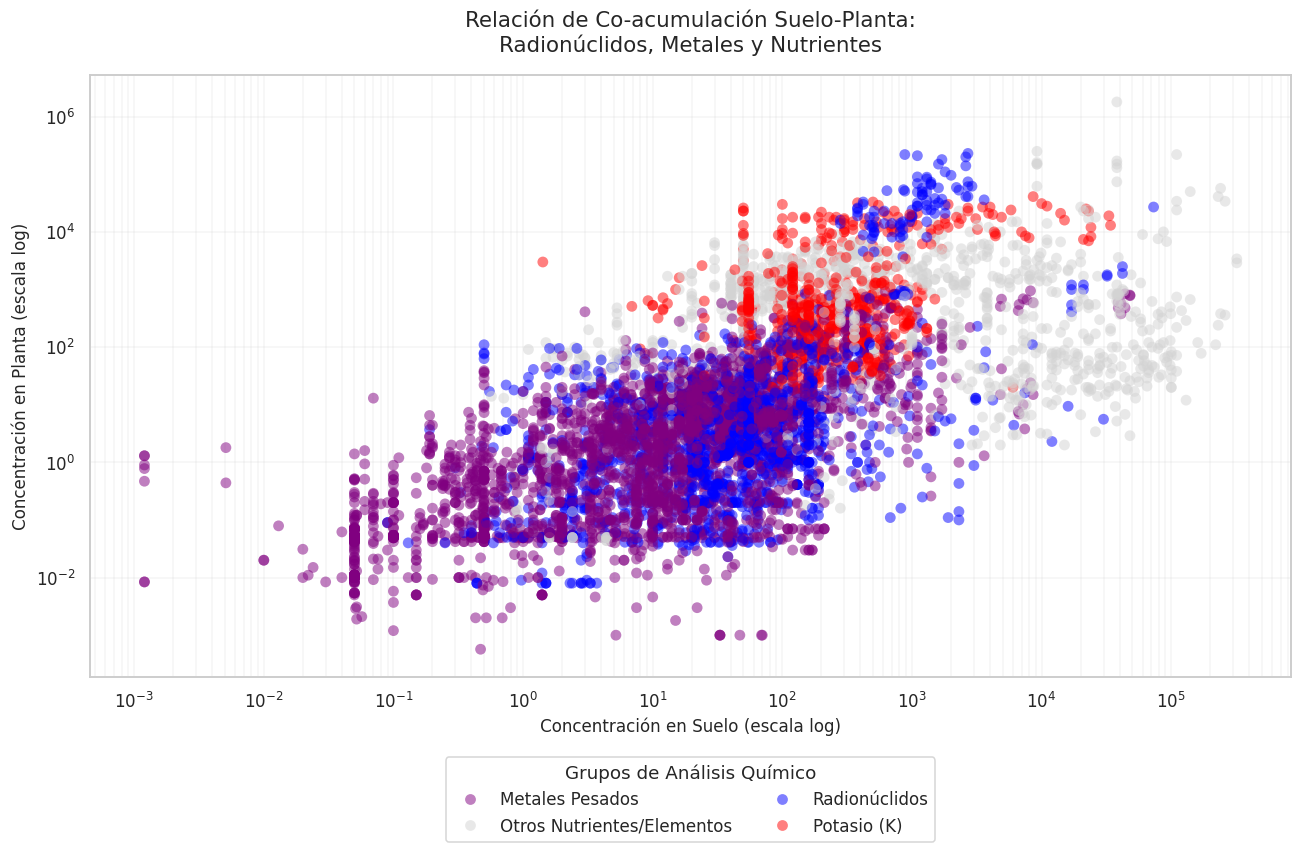

In [ ]:
# --- Scatter Suelo-Planta por grupo químico ---
plt.figure(figsize=(12, 8))

colores_tesis = {
    'Radionúclidos'             : 'blue',
    'Potasio (K)'               : 'red',
    'Metales Pesados'           : 'purple',
    'Otros Nutrientes/Elementos': 'lightgrey',
}

df_scatter = df[df['C_soil_num'].notna() & df['C_plant_num'].notna()].copy()
df_scatter = df_scatter[(df_scatter['C_soil_num'] > 0) & (df_scatter['C_plant_num'] > 0)]

sns.scatterplot(data=df_scatter, x='C_soil_num', y='C_plant_num',
                hue='Grupo', palette=colores_tesis, alpha=0.5, s=50,
                edgecolor='none')

plt.xscale('log')
plt.yscale('log')
plt.title("Relación de Co-acumulación Suelo-Planta:\nRadionúclidos, Metales y Nutrientes",
          fontsize=14, pad=15)
plt.xlabel("Concentración en Suelo (escala log)", fontsize=11)
plt.ylabel("Concentración en Planta (escala log)", fontsize=11)
plt.legend(title="Grupos de Análisis Químico", loc='upper center',
           bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

### 7.2 Boxplot de CR por elemento

Compara la bioacumulación entre los 36 elementos del dataset. La línea horizontal CR=1
es el **umbral de bioacumulación**: por encima, la planta concentra el elemento; por
debajo, lo excluye.


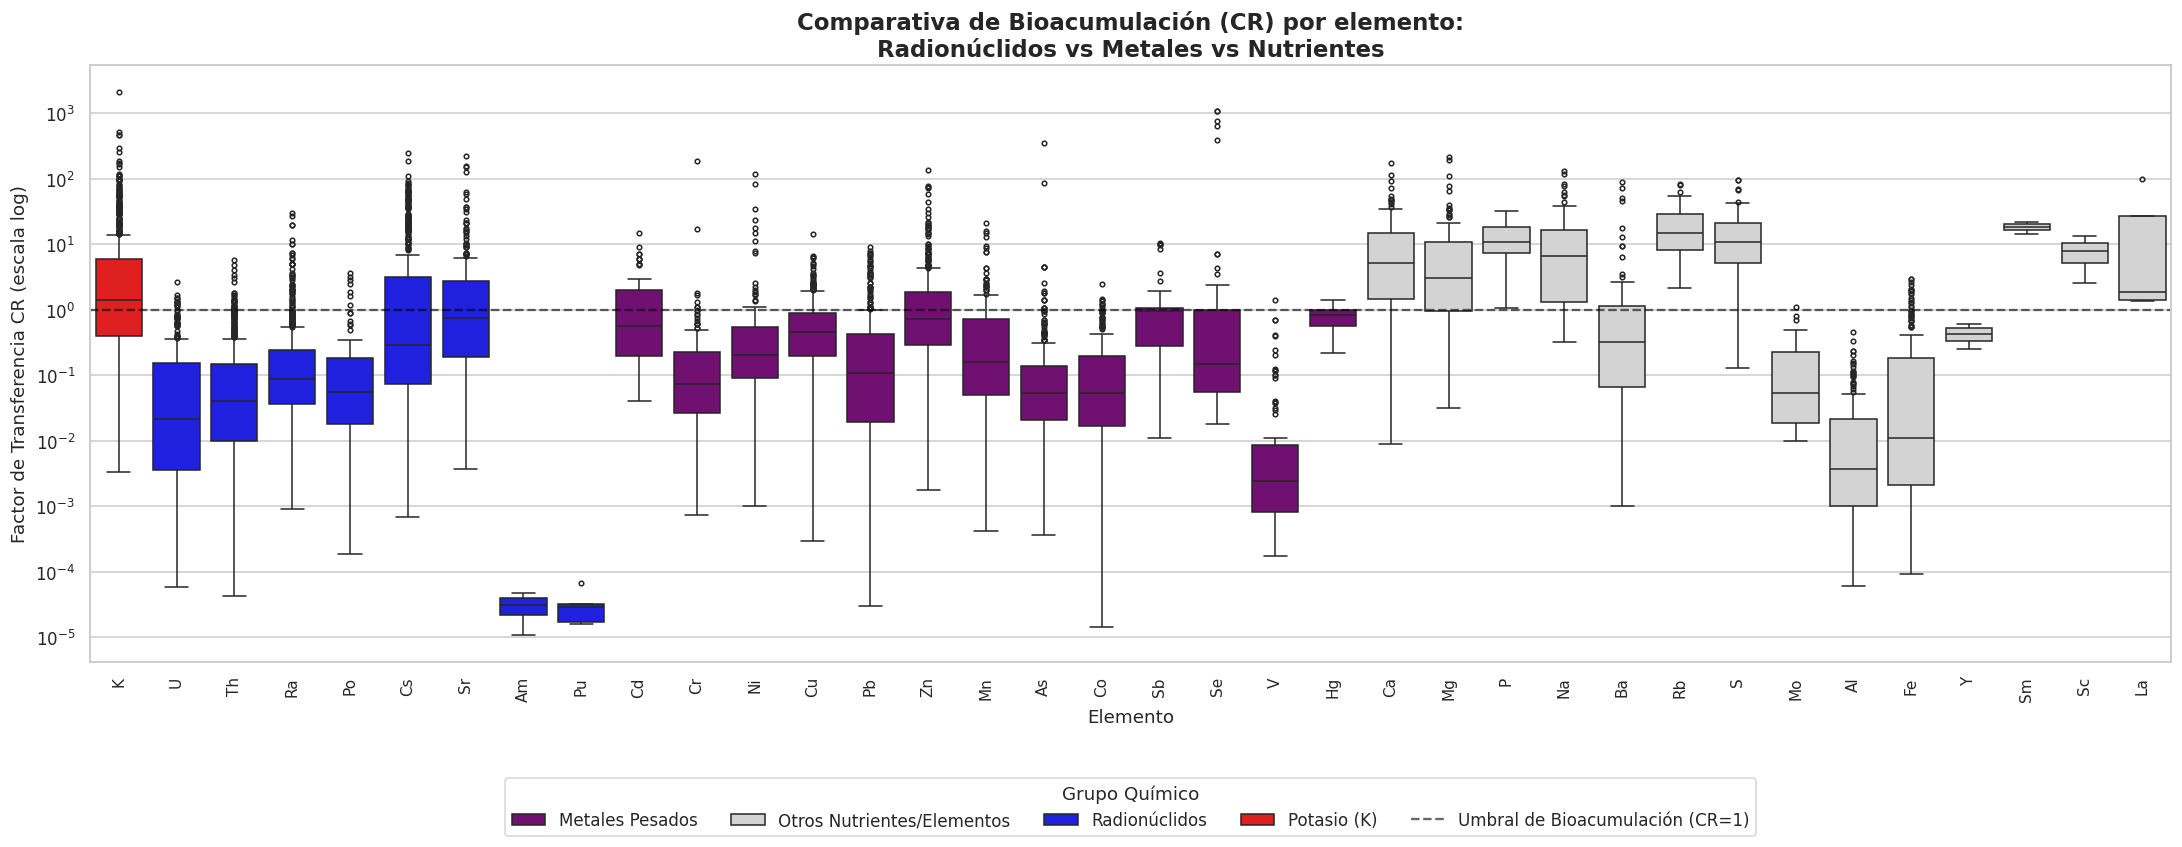

In [ ]:
# --- Boxplot CR por elemento (los 36) ---
plt.figure(figsize=(20, 8))
sns.set_style("whitegrid")

paleta_tesis = {
    'Potasio (K)': 'red',
    'Radionúclidos': 'blue',
    'Metales Pesados': 'purple',
    'Otros Nutrientes/Elementos': 'lightgrey',
    'Otros': 'darkgrey',
}

orden_total = ['K'] + rad_list + metales_list + nutrientes_list
elementos_presentes = [e for e in orden_total if e in df['Element'].unique()]

df_box = df[df['CR_final'].notna() & (df['CR_final'] > 0)].copy()

sns.boxplot(data=df_box, x='Element', y='CR_final', hue='Grupo',
            palette=paleta_tesis, order=elementos_presentes,
            dodge=False, fliersize=3)

plt.yscale('log')
plt.axhline(y=1, color='black', linestyle='--', alpha=0.6,
            label='Umbral de Bioacumulación (CR=1)')
plt.title("Comparativa de Bioacumulación (CR) por elemento:\n"
          "Radionúclidos vs Metales vs Nutrientes",
          fontsize=15, fontweight='bold')
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("Factor de Transferencia CR (escala log)")
plt.xlabel("Elemento")
plt.legend(title="Grupo Químico", loc='upper center',
           bbox_to_anchor=(0.5, -0.18), ncol=5)
plt.tight_layout()
plt.show()

---
## 8. Análisis de dispersión por radionúclido (Entrega 2)

Para cada uno de los 6 radionúclidos clave (Cs, Ra, Th, U, K, Pb) generamos la gráfica
de dispersión característica de la entrega 2: histograma con KDE + líneas de media, ±1σ,
mínimo y máximo, y un recuadro con todas las medidas de dispersión.

Esta es la **forma más efectiva** de visualizar la distribución de una variable: muestra a la vez la forma, la tendencia central y la dispersión.


In [ ]:
# --- Lista de radionúclidos a analizar ---
radionuclidos_analisis = ['Cs', 'Ra', 'Th', 'U', 'K', 'Pb']

# Verificar disponibilidad
print("Muestras disponibles por radionúclido (CR_final):")
for el in radionuclidos_analisis:
    n = ((df['Element']==el) & df['CR_final'].notna()).sum()
    print(f"  {el}: {n} muestras")

Muestras disponibles por radionúclido (CR_final):
  Cs: 433 muestras
  Ra: 665 muestras
  Th: 535 muestras
  U: 268 muestras
  K: 775 muestras
  Pb: 555 muestras


In [ ]:
# --- Función para gráfica de dispersión estilo SP2 ---
def grafica_dispersion_sp2(elemento, variable='CR_final', color='skyblue'):
    # Genera la gráfica de dispersión estilo SP2 para un elemento dado.
    datos = df[df['Element']==elemento][variable].dropna()
    datos = datos[datos > 0]

    if len(datos) < 10:
        print(f"  {elemento}: muestras insuficientes ({len(datos)})")
        return None

    # Estadísticas
    media = np.mean(datos)
    mediana = np.median(datos)
    minimo, maximo = datos.min(), datos.max()
    rango = maximo - minimo
    varianza = np.var(datos, ddof=1)
    desviacion = np.std(datos, ddof=1)
    coef_var = (desviacion / media) * 100

    # Gráfica
    plt.figure(figsize=(12, 7))
    sns.histplot(datos, bins=40, kde=True, color=color)

    plt.axvline(media, color='green', linestyle='--', linewidth=2,
                label=f'Media = {media:.2f}')
    plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5,
                label=f'+1σ = {media + desviacion:.2f}')
    if (media - desviacion) > minimo:
        plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5,
                    label=f'-1σ = {media - desviacion:.2f}')
    plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5,
                label=f'Mínimo = {minimo:.3f}')
    plt.axvline(maximo, color='orange', linestyle='-', linewidth=1.5,
                label=f'Máximo = {maximo:.2f}')

    plt.xscale('log')   # log porque la distribución es muy sesgada
    plt.title(f"Análisis de Dispersión — CR de {elemento}",
              fontsize=14, fontweight='bold')
    plt.xlabel(f"CR de {elemento} (escala log)", fontsize=12)
    plt.ylabel("Frecuencia (n° de muestras)", fontsize=12)
    plt.legend(loc='upper right', fontsize=9)

    texto = (f"n = {len(datos)}\n"
             f"Rango: {rango:.2f}\n"
             f"Varianza: {varianza:.2e}\n"
             f"Desviación: {desviacion:.2f}\n"
             f"Coef. var: {coef_var:.1f}%\n"
             f"Asimetría: {skew(datos):.2f}\n"
             f"Curtosis: {kurtosis(datos):.2f}")
    plt.text(0.02, 0.55, texto, transform=plt.gca().transAxes,
             bbox=dict(facecolor='lightgreen', alpha=0.4), fontsize=10)

    plt.tight_layout()
    plt.show()

    return {'n': len(datos), 'media': media, 'mediana': mediana,
            'desviacion': desviacion, 'cv': coef_var,
            'skew': skew(datos), 'kurtosis': kurtosis(datos),
            'min': minimo, 'max': maximo}


  Radionúclido: Cs


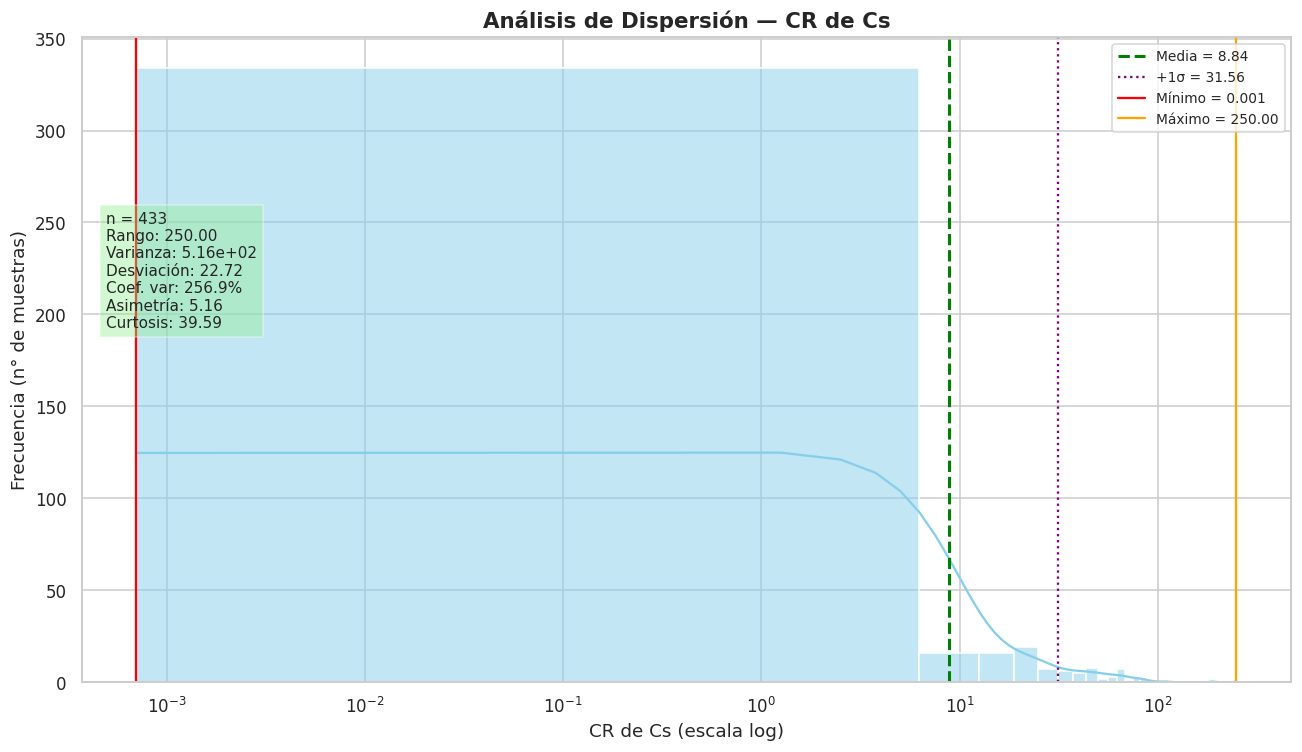


  Radionúclido: Ra


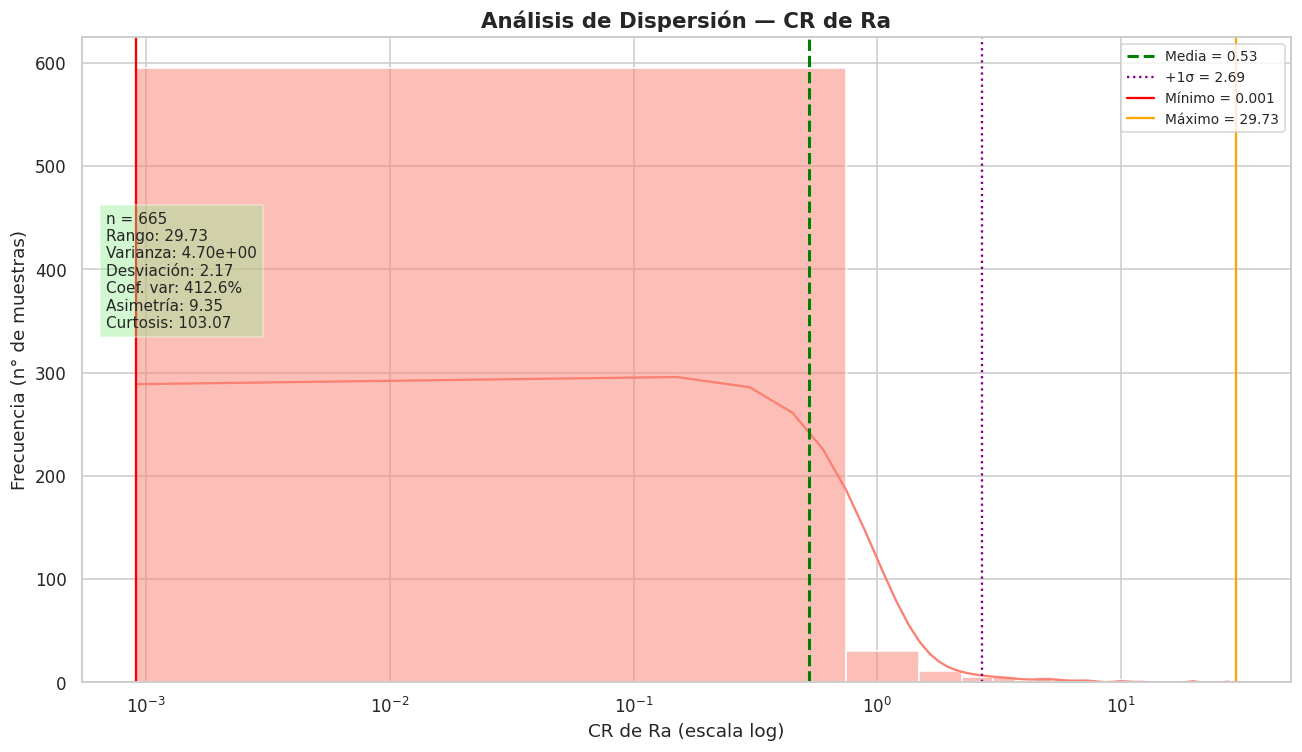


  Radionúclido: Th


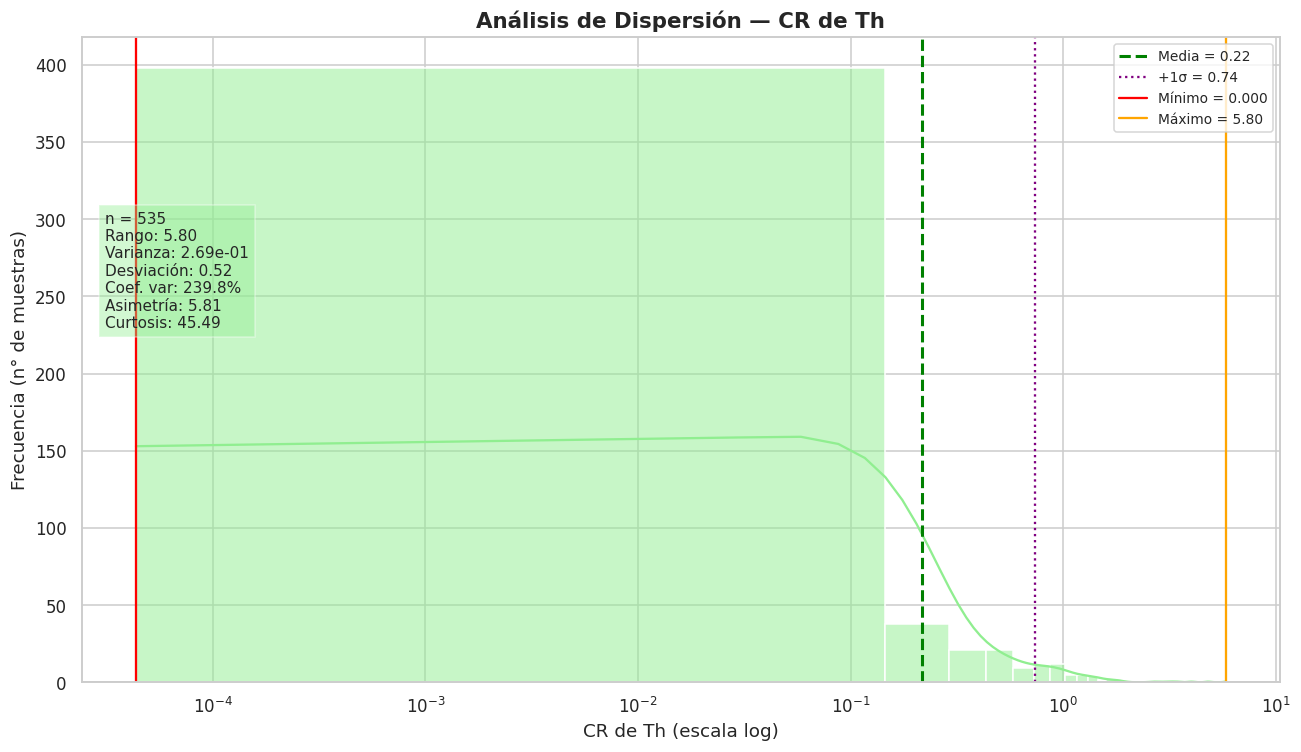


  Radionúclido: U


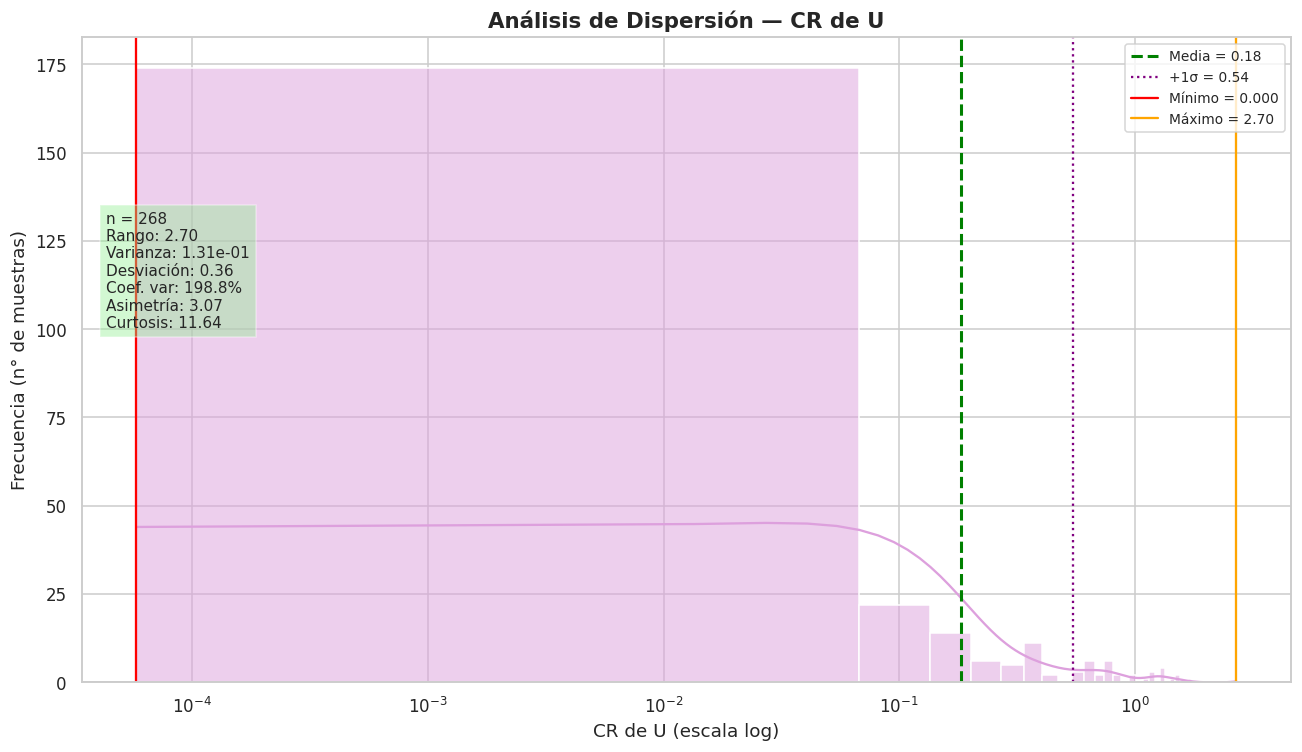


  Radionúclido: K


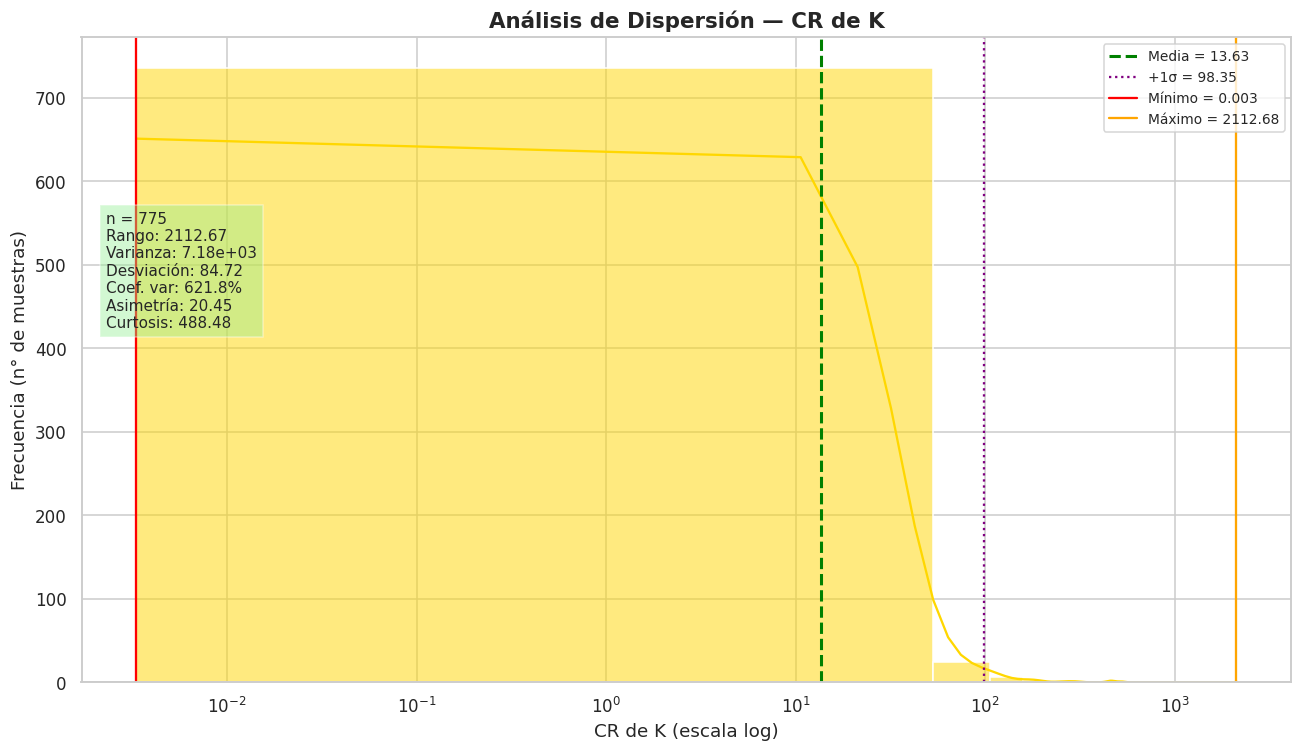


  Radionúclido: Pb


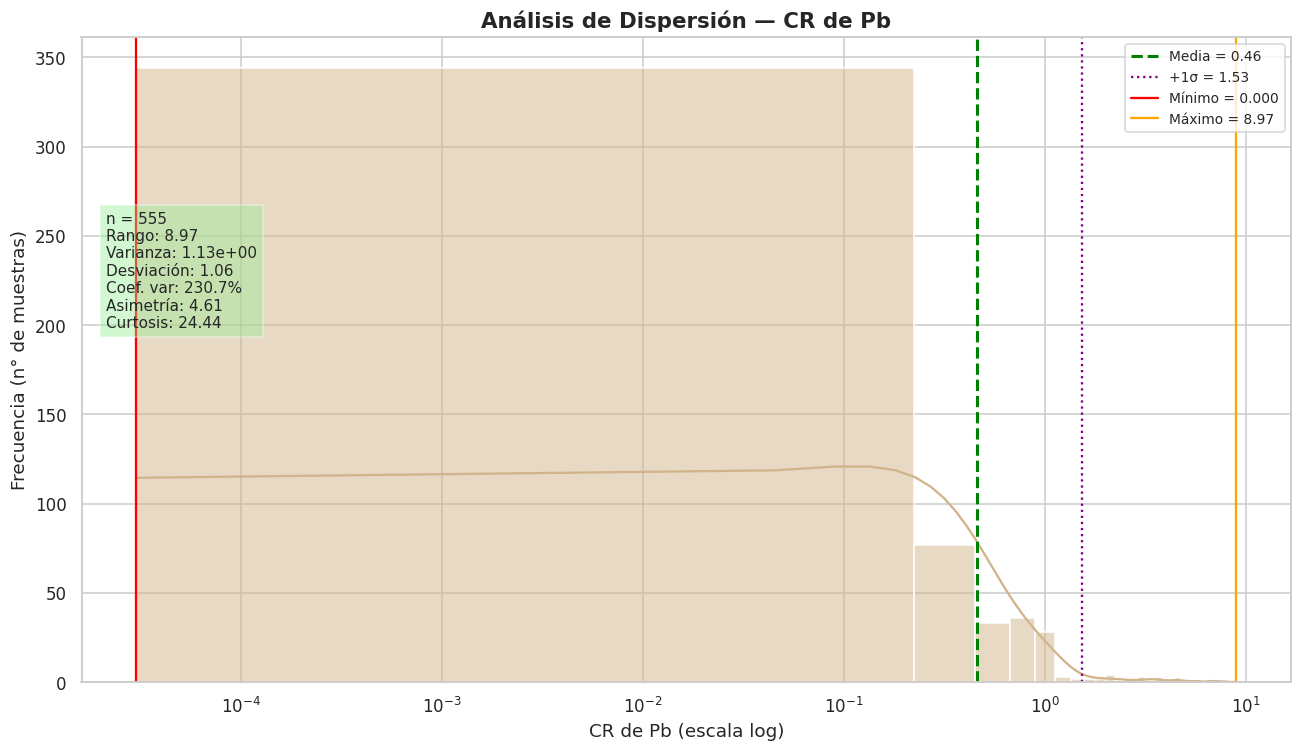

In [ ]:
# --- Generar dispersión SP2 para cada radionúclido ---
colores_rad = {'Cs':'skyblue','Ra':'salmon','Th':'lightgreen','U':'plum','K':'gold','Pb':'tan'}
estadisticas_radio = {}

for el in radionuclidos_analisis:
    print(f"\n{'='*60}")
    print(f"  Radionúclido: {el}")
    print('='*60)
    estadisticas_radio[el] = grafica_dispersion_sp2(el, color=colores_rad[el])

---
## 9. Técnicas de escalado por radionúclido

El **escalado** transforma los valores para que estén en un rango comparable, sin cambiar
la forma de la distribución. Es esencial cuando combinamos variables con escalas
diferentes (por ejemplo en PCA o regresión múltiple).

Comparamos las **4 técnicas**, para cada radionúclido mostramos la distribución original + las 4 versiones escaladas, y
una **tabla comparativa** con media, mediana y desviación de cada una.


In [ ]:
# --- Función para comparar escalados ---
def comparar_escalados(elemento, variable='CR_final'):
    datos = df[df['Element']==elemento][variable].dropna()
    datos = datos[datos > 0].values.reshape(-1, 1)
    if len(datos) < 10:
        print(f"  {elemento}: muestras insuficientes")
        return None

    # Aplicar las 4 técnicas
    original = datos.flatten()
    std_s    = StandardScaler().fit_transform(datos).flatten()
    minmax_s = MinMaxScaler().fit_transform(datos).flatten()
    robust_s = RobustScaler().fit_transform(datos).flatten()
    zscore_s = (original - original.mean()) / original.std()

    versiones = {
        'Original'       : original,
        'StandardScaler' : std_s,
        'MinMaxScaler'   : minmax_s,
        'RobustScaler'   : robust_s,
        'Z-Score'        : zscore_s,
    }

    # Gráfica
    fig, axs = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(f"Técnicas de escalado — CR de {elemento}",
                 fontsize=14, fontweight='bold', y=1.05)

    colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']
    for ax, (nombre, d), color in zip(axs, versiones.items(), colors):
        sns.histplot(d, bins=30, kde=True, color=color, ax=ax)
        ax.set_title(f"{nombre}\nmean={d.mean():.2f} | std={d.std():.2f}",
                     fontsize=10)
        ax.set_xlabel("")

    plt.tight_layout()
    plt.show()

    # Tabla comparativa
    tabla = pd.DataFrame({
        'Técnica'  : list(versiones.keys()),
        'Media'    : [d.mean() for d in versiones.values()],
        'Mediana'  : [np.median(d) for d in versiones.values()],
        'Desv. est.': [d.std() for d in versiones.values()],
        'Min'      : [d.min() for d in versiones.values()],
        'Max'      : [d.max() for d in versiones.values()],
    }).round(3)

    print(f"Tabla comparativa de escalados — {elemento}:")
    print(tabla.to_string(index=False))
    return tabla


  Radionúclido: Cs


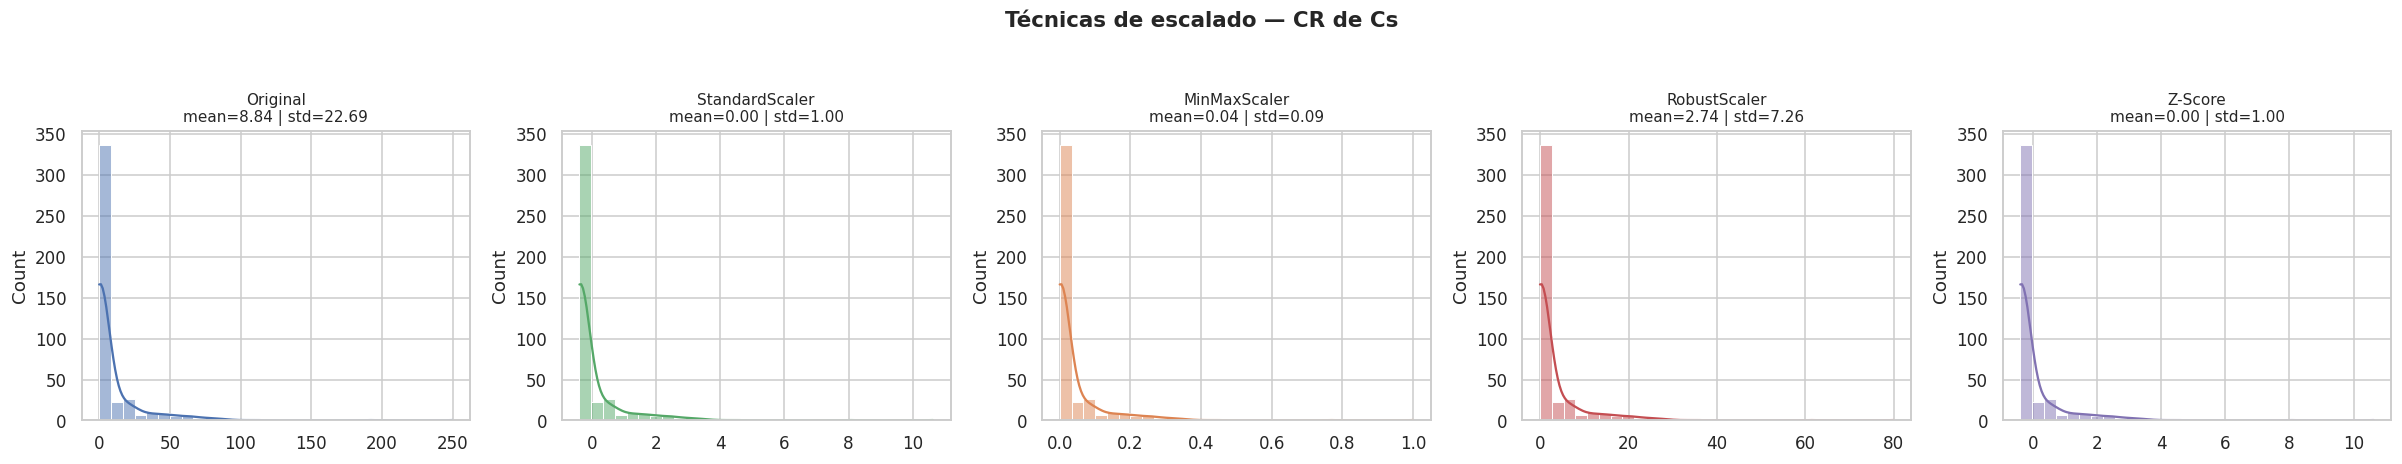

Tabla comparativa de escalados — Cs:
       Técnica  Media  Mediana  Desv. est.    Min     Max
      Original  8.843    0.290      22.689  0.001 250.000
StandardScaler  0.000   -0.377       1.000 -0.390  10.629
  MinMaxScaler  0.035    0.001       0.091  0.000   1.000
  RobustScaler  2.737    0.000       7.261 -0.093  79.907
       Z-Score  0.000   -0.377       1.000 -0.390  10.629

  Radionúclido: Ra


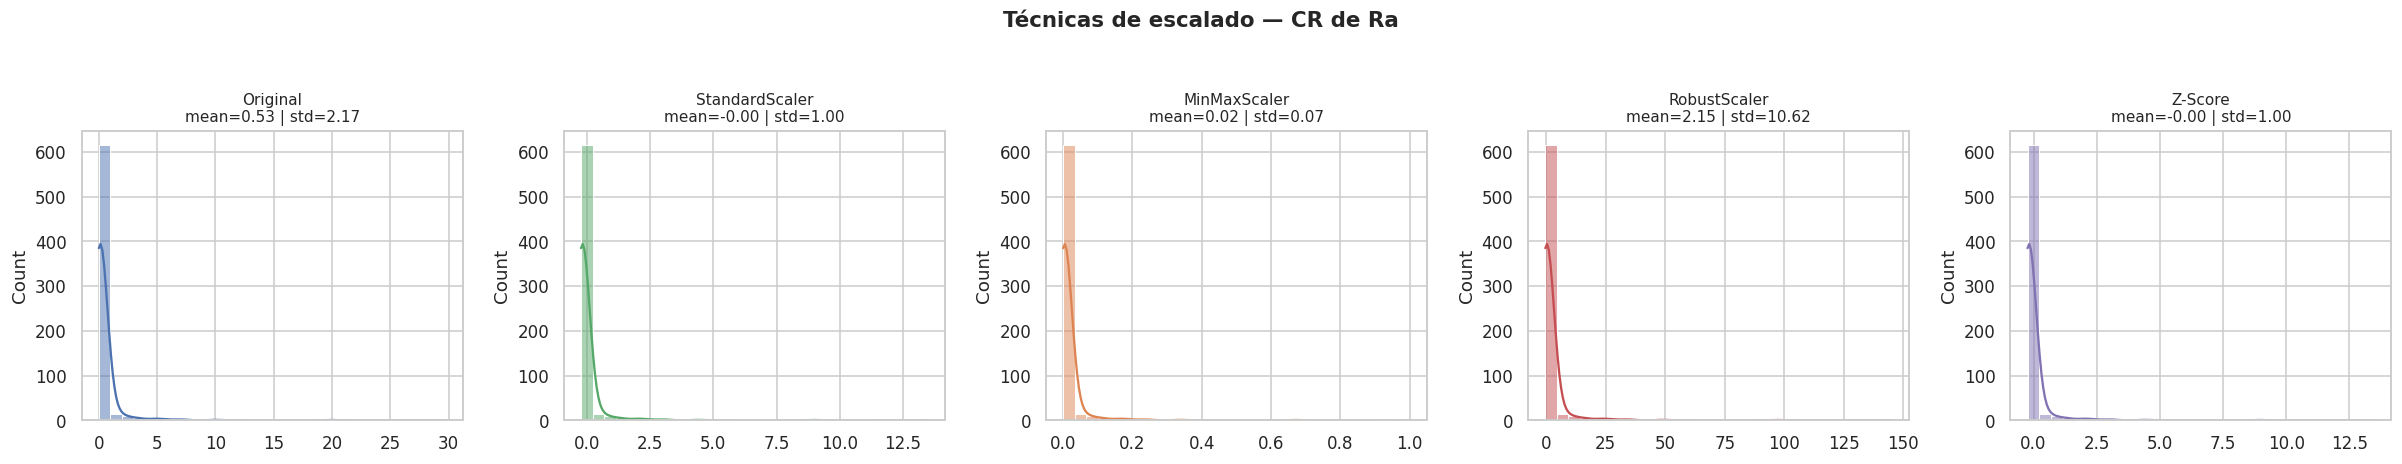

Tabla comparativa de escalados — Ra:
       Técnica  Media  Mediana  Desv. est.    Min     Max
      Original  0.526    0.087       2.167  0.001  29.730
StandardScaler -0.000   -0.202       1.000 -0.242  13.479
  MinMaxScaler  0.018    0.003       0.073  0.000   1.000
  RobustScaler  2.150    0.000      10.621 -0.422 145.307
       Z-Score -0.000   -0.202       1.000 -0.242  13.479

  Radionúclido: Th


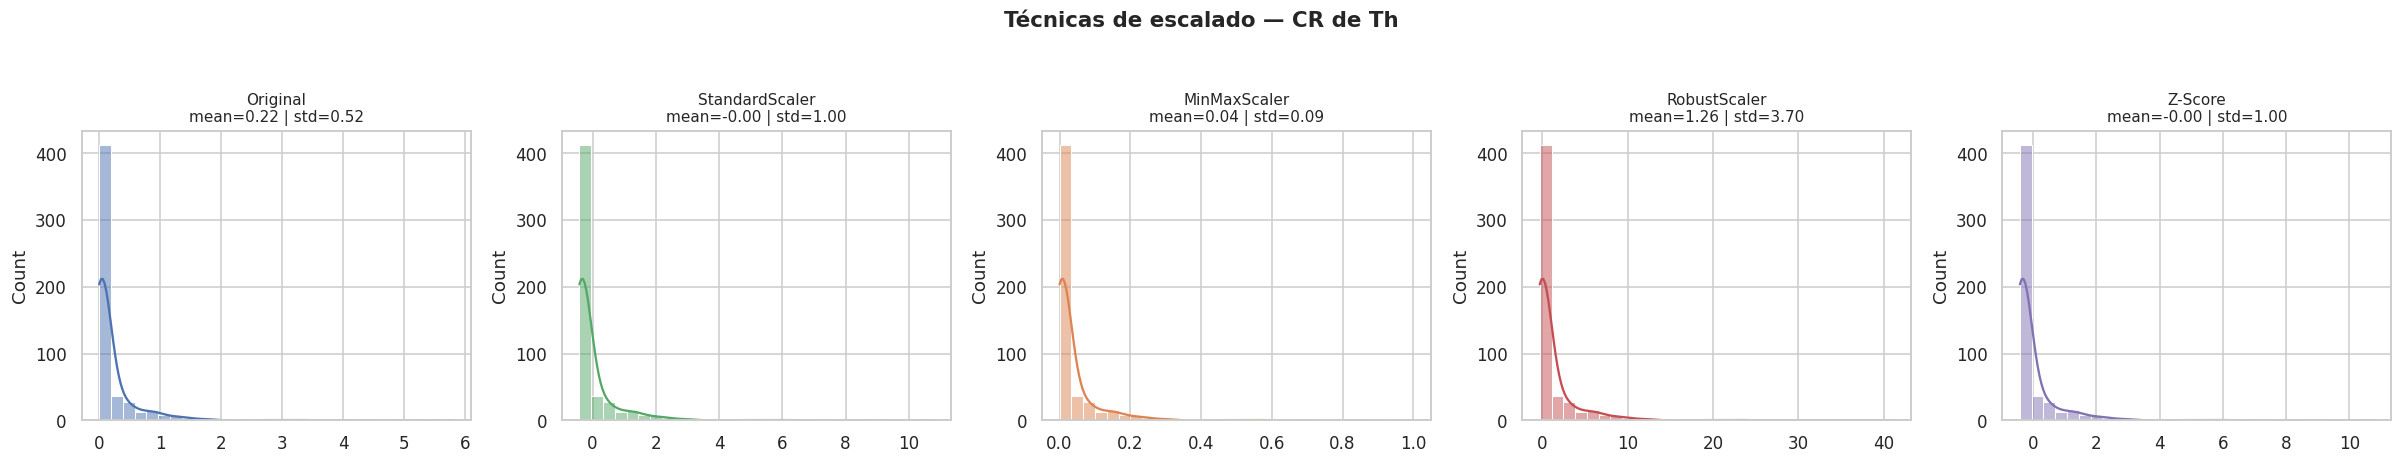

Tabla comparativa de escalados — Th:
       Técnica  Media  Mediana  Desv. est.    Min    Max
      Original  0.216    0.040       0.518  0.000  5.800
StandardScaler -0.000   -0.340       1.000 -0.417 10.770
  MinMaxScaler  0.037    0.007       0.089  0.000  1.000
  RobustScaler  1.260    0.000       3.703 -0.285 41.143
       Z-Score -0.000   -0.340       1.000 -0.417 10.770

  Radionúclido: U


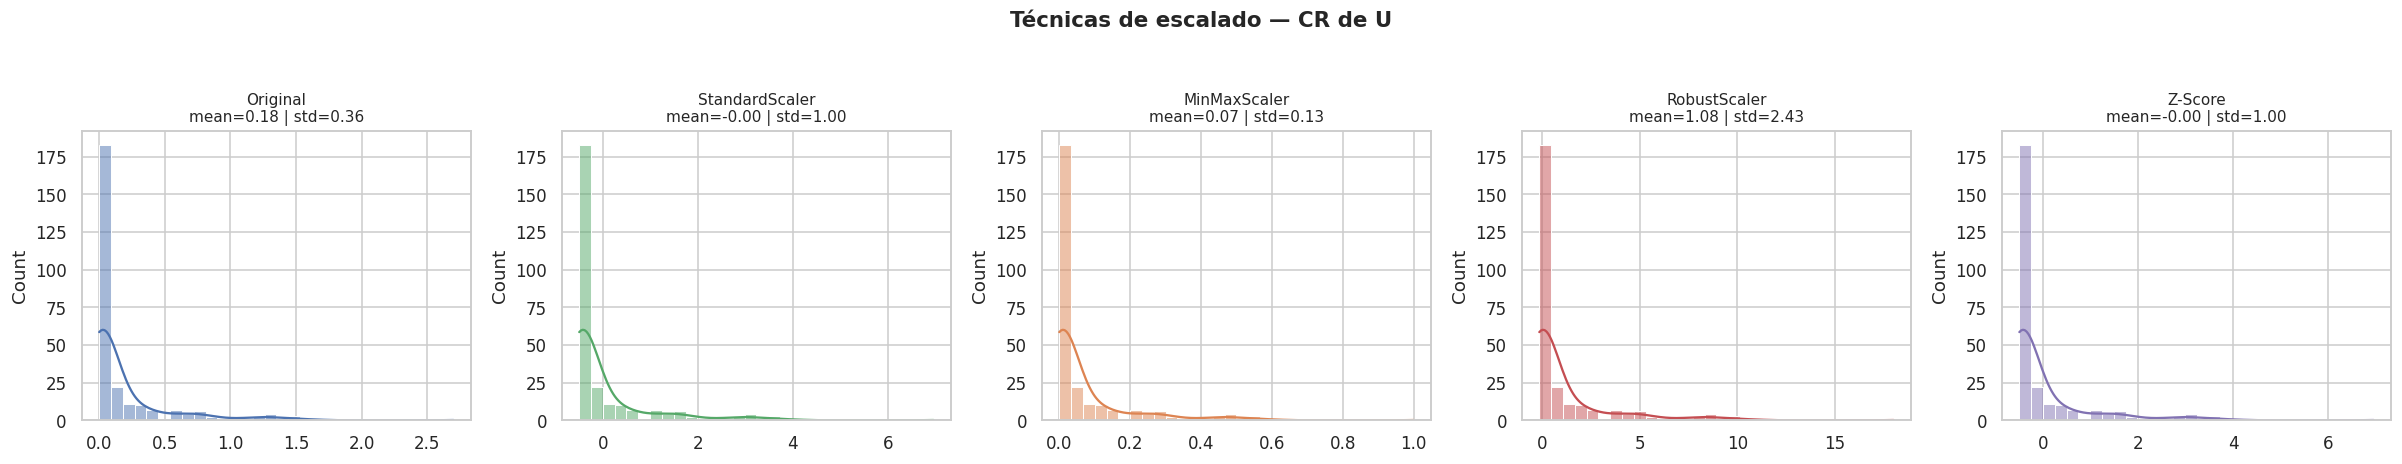

Tabla comparativa de escalados — U:
       Técnica  Media  Mediana  Desv. est.    Min    Max
      Original  0.182    0.021       0.361  0.000  2.700
StandardScaler -0.000   -0.445       1.000 -0.504  6.966
  MinMaxScaler  0.067    0.008       0.134  0.000  1.000
  RobustScaler  1.080    0.000       2.428 -0.144 17.995
       Z-Score -0.000   -0.445       1.000 -0.504  6.966

  Radionúclido: K


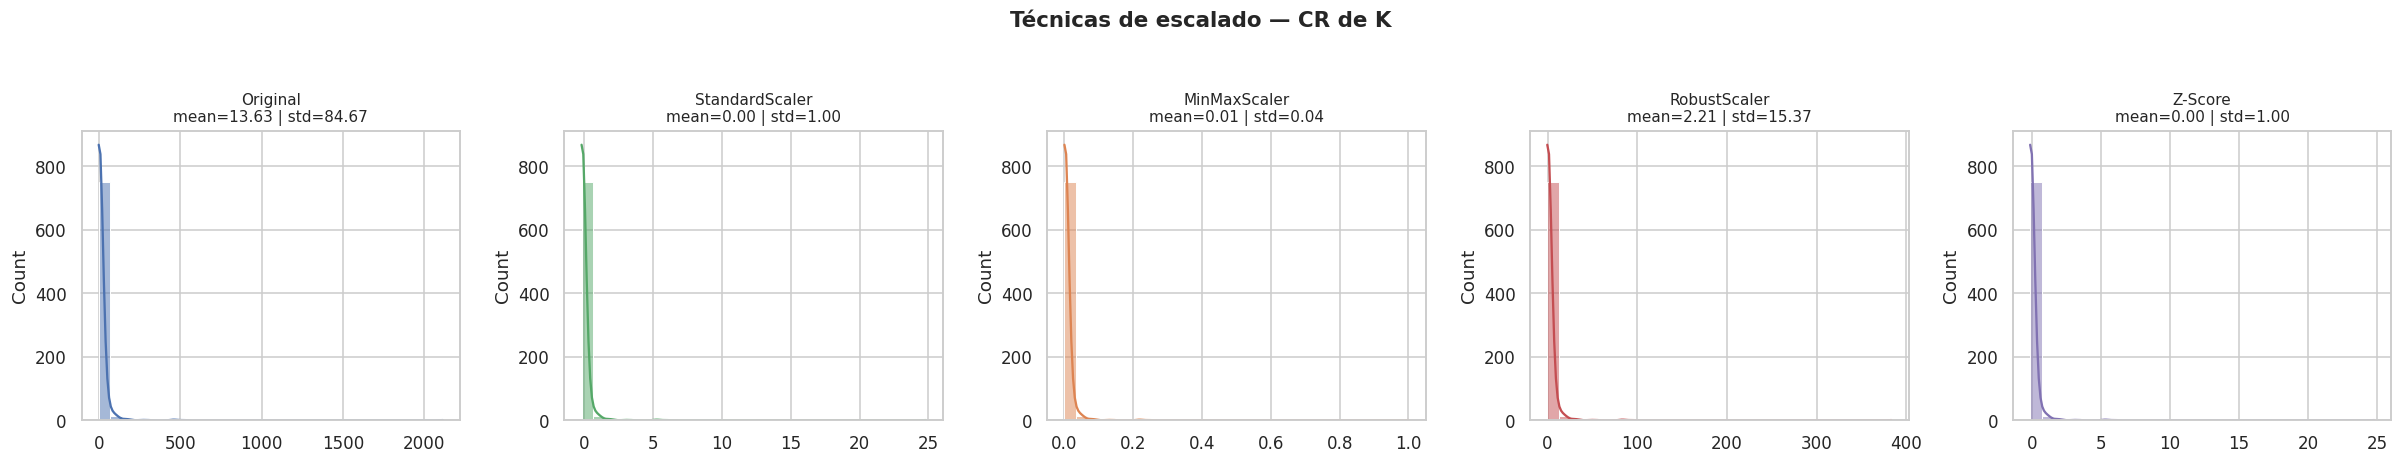

Tabla comparativa de escalados — K:
       Técnica  Media  Mediana  Desv. est.    Min      Max
      Original 13.626    1.429      84.665  0.003 2112.676
StandardScaler  0.000   -0.144       1.000 -0.161   24.792
  MinMaxScaler  0.006    0.001       0.040  0.000    1.000
  RobustScaler  2.214    0.000      15.368 -0.259  383.230
       Z-Score  0.000   -0.144       1.000 -0.161   24.792

  Radionúclido: Pb


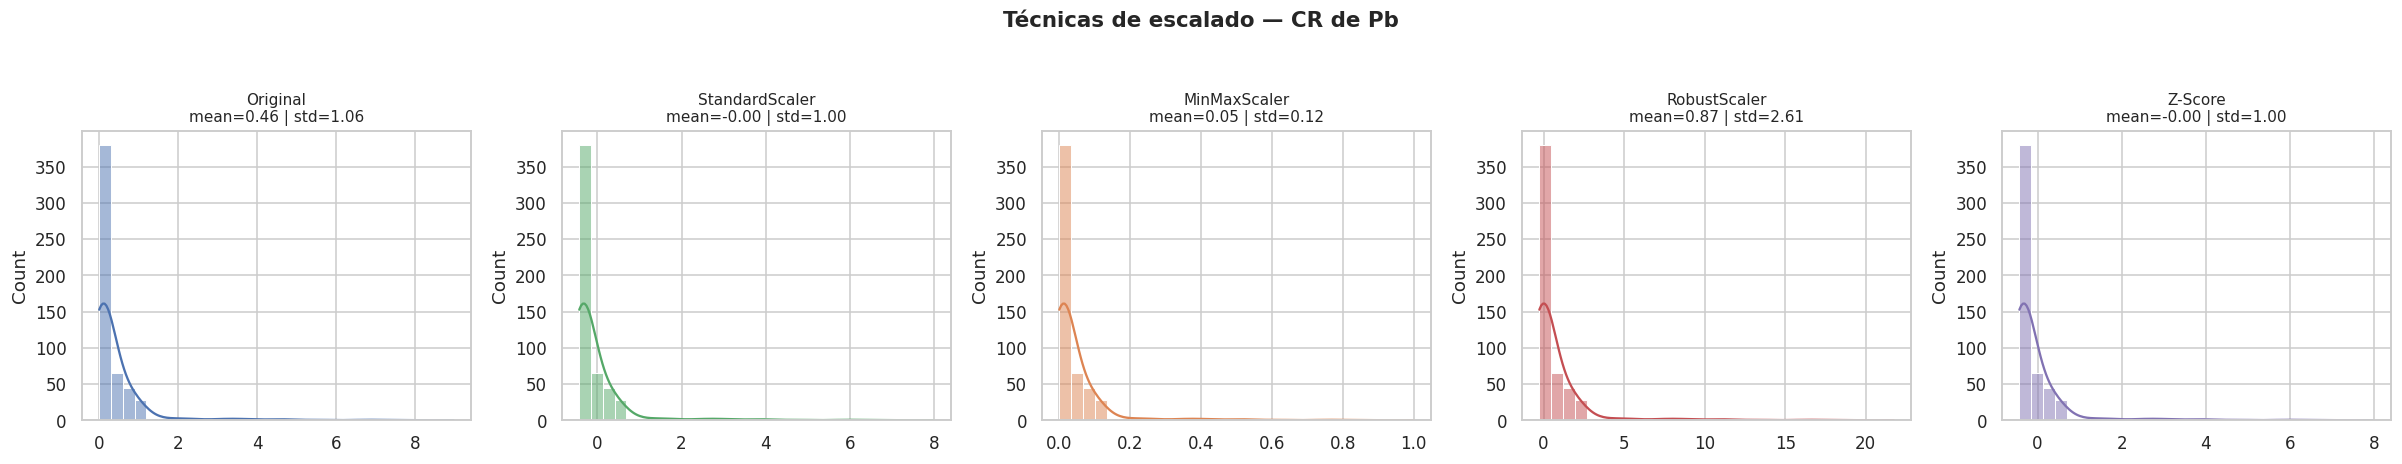

Tabla comparativa de escalados — Pb:
       Técnica  Media  Mediana  Desv. est.    Min    Max
      Original  0.461    0.109       1.063  0.000  8.966
StandardScaler -0.000   -0.332       1.000 -0.434  7.996
  MinMaxScaler  0.051    0.012       0.119  0.000  1.000
  RobustScaler  0.865    0.000       2.610 -0.267 21.733
       Z-Score -0.000   -0.332       1.000 -0.434  7.996


In [ ]:
# --- Aplicar comparación de escalados a cada radionúclido ---
for el in radionuclidos_analisis:
    print(f"\n{'='*60}")
    print(f"  Radionúclido: {el}")
    print('='*60)
    comparar_escalados(el)

**Interpretación (para el artículo):**

- **StandardScaler / Z-Score** son equivalentes: ambos centran en 0 con desv 1, pero NO
  corrigen la asimetría.
- **MinMaxScaler** mantiene la forma de la distribución pero la comprime al rango [0, 1].
- **RobustScaler** es el más adecuado para datos con outliers (como los nuestros): usa
  mediana e IQR, así que los hotspots no distorsionan el escalado.

> **Conclusión:** el escalado NO normaliza la distribución (sigue siendo asimétrica).
> Para corregir la asimetría hay que **transformar**, no escalar. Eso lo hacemos en la
> Sección 10.


---
## 10. Técnicas de transformación por radionúclido

A diferencia del escalado, una **transformación** SÍ cambia la forma de la distribución.
Su objetivo es corregir la asimetría (skewness) y aproximar a una distribución normal.

Comparamos las **4 técnicas** de la entrega:

| Técnica | Cuándo sirve | Restricción |
|---|---|---|
| **Logarítmica** `log1p(x)` | asimetría positiva fuerte | x ≥ 0 |
| **Raíz cuadrada** `sqrt(x)` | asimetría positiva moderada | x ≥ 0 |
| **Box-Cox** | optimiza un λ para minimizar asimetría | x > 0 estricto |
| **Yeo-Johnson** | versión generalizada de Box-Cox | admite ceros y negativos |

**Criterio de selección:** la transformación con **asimetría más cercana a 0**.


In [ ]:
# --- Función para comparar transformaciones ---
def comparar_transformaciones(elemento, variable='CR_final'):
    datos = df[df['Element']==elemento][variable].dropna()
    datos = datos[datos > 0].values

    if len(datos) < 10:
        return None

    # Aplicar las 4 transformaciones
    original = datos
    log_t    = np.log1p(datos)
    sqrt_t   = np.sqrt(datos)
    try:
        boxcox_t, lambda_bc = boxcox(datos)
    except Exception:
        boxcox_t = np.full_like(datos, np.nan)
        lambda_bc = np.nan
    yj_t = PowerTransformer(method='yeo-johnson').fit_transform(
        datos.reshape(-1, 1)).flatten()

    versiones = {
        'Original'      : original,
        'Logarítmica'   : log_t,
        'Raíz cuadrada' : sqrt_t,
        f'Box-Cox (λ={lambda_bc:.2f})' : boxcox_t,
        'Yeo-Johnson'   : yj_t,
    }

    # Gráfica
    fig, axs = plt.subplots(1, 5, figsize=(22, 4))
    fig.suptitle(f"Técnicas de transformación — CR de {elemento}",
                 fontsize=14, fontweight='bold', y=1.05)
    colors = ['#4C72B0','#55A868','#C44E52','#DD8452','#8172B2']
    for ax, (nombre, d), color in zip(axs, versiones.items(), colors):
        if np.isnan(d).all():
            ax.text(0.5, 0.5, "No aplicable", ha='center')
            ax.set_title(nombre)
            continue
        sns.histplot(d, bins=30, kde=True, color=color, ax=ax)
        ax.set_title(f"{nombre}\nskew = {skew(d):.2f}", fontsize=10)
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

    # Tabla comparativa
    tabla = pd.DataFrame({
        'Transformación': list(versiones.keys()),
        'Asimetría'     : [round(skew(d), 3) if not np.isnan(d).all() else None
                          for d in versiones.values()],
        'Curtosis'      : [round(kurtosis(d), 3) if not np.isnan(d).all() else None
                          for d in versiones.values()],
        'Media'         : [round(d.mean(), 3) if not np.isnan(d).all() else None
                          for d in versiones.values()],
        'Desv. est.'    : [round(d.std(), 3) if not np.isnan(d).all() else None
                          for d in versiones.values()],
    })

    # Identificar la mejor (asimetría más cercana a 0)
    asims_validos = [(t, a) for t, a in zip(tabla['Transformación'], tabla['Asimetría'])
                     if a is not None and t != 'Original']
    mejor = min(asims_validos, key=lambda x: abs(x[1]))
    print(f"Tabla — {elemento}:")
    print(tabla.to_string(index=False))
    print(f"\n  >>> MEJOR para {elemento}: {mejor[0]} (skew = {mejor[1]})")
    return tabla, mejor


  Radionúclido: Cs


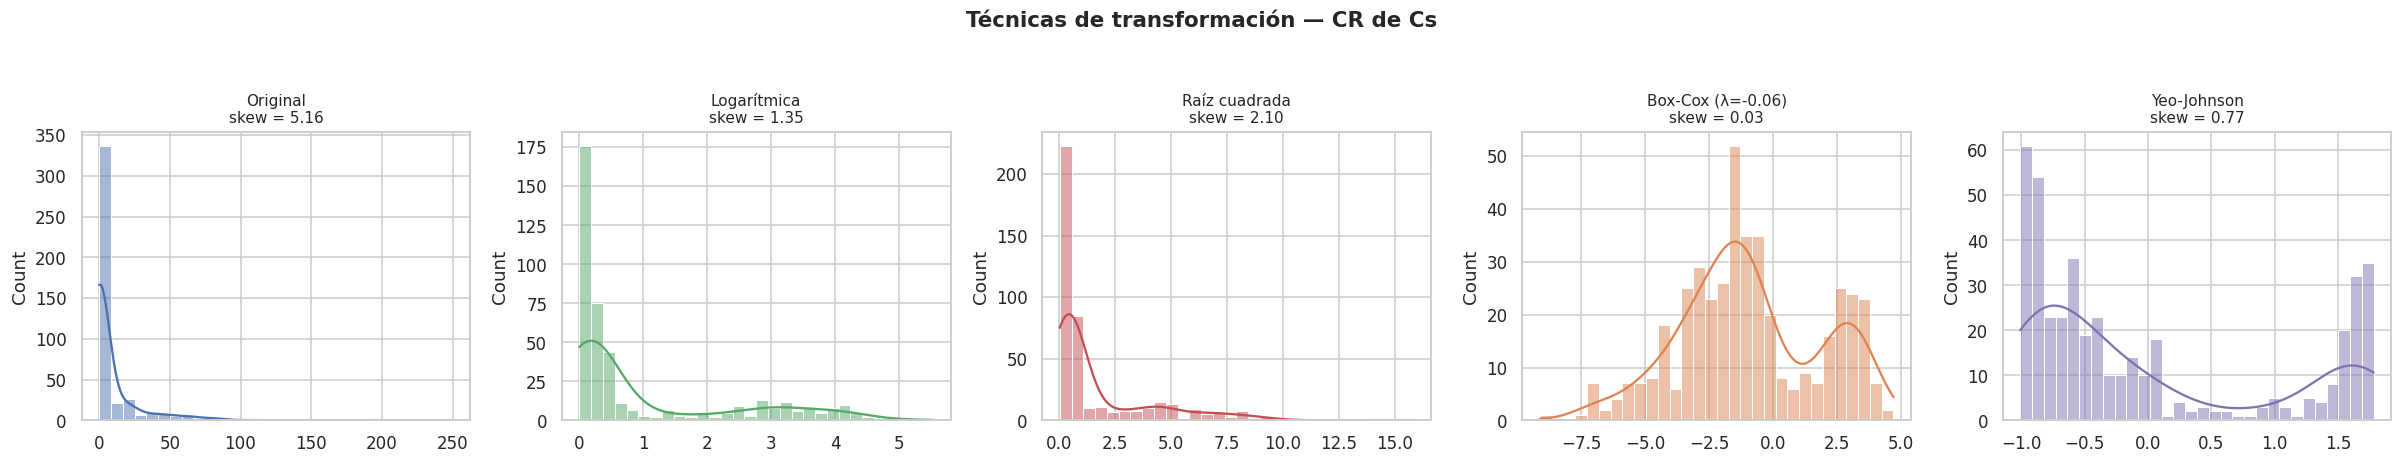

Tabla — Cs:
   Transformación  Asimetría  Curtosis  Media  Desv. est.
         Original      5.160    39.586  8.843      22.689
      Logarítmica      1.352     0.348  0.989       1.378
    Raíz cuadrada      2.098     4.689  1.694       2.444
Box-Cox (λ=-0.06)      0.032    -0.510 -0.964       2.741
      Yeo-Johnson      0.769    -1.058 -0.000       1.000

  >>> MEJOR para Cs: Box-Cox (λ=-0.06) (skew = 0.032)

  Radionúclido: Ra


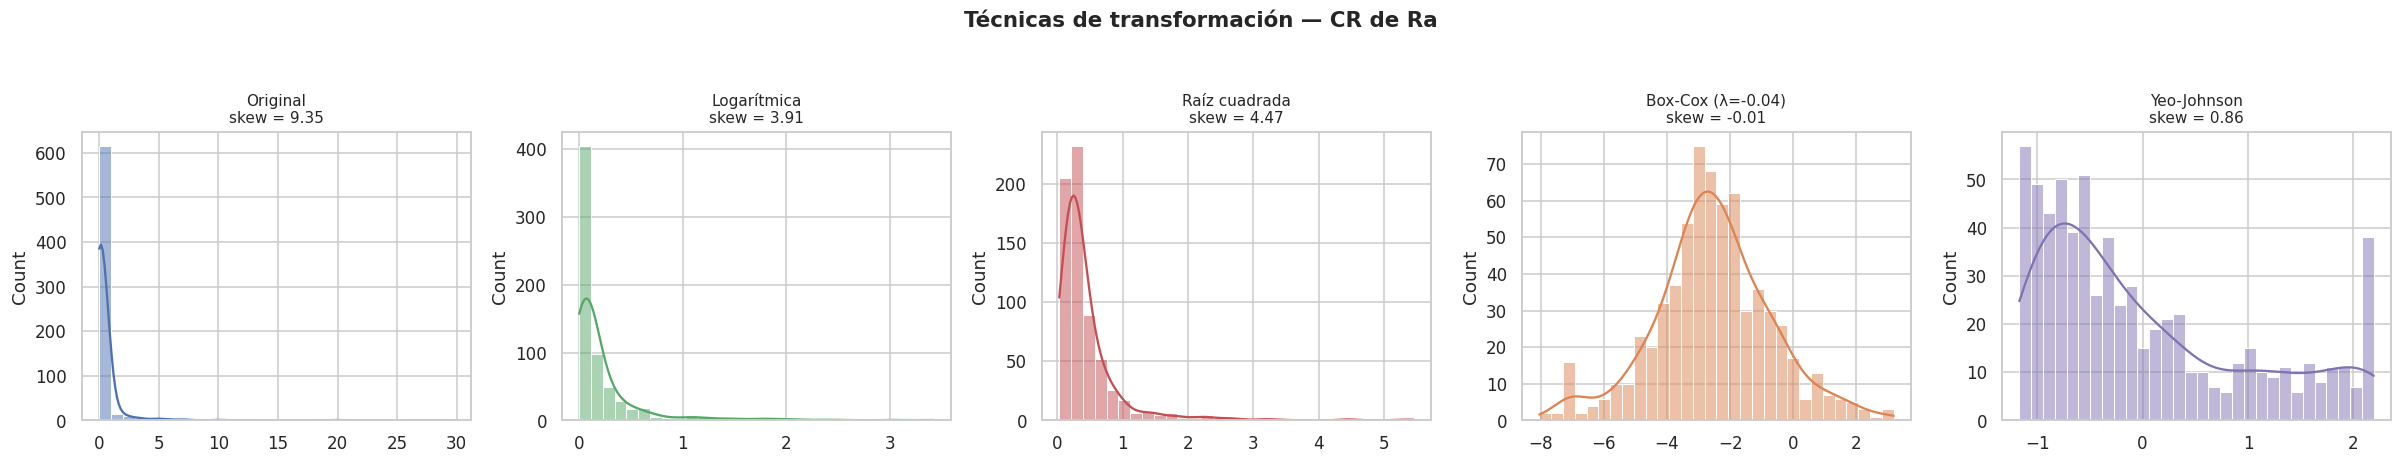

Tabla — Ra:
   Transformación  Asimetría  Curtosis  Media  Desv. est.
         Original      9.348   103.071  0.526       2.167
      Logarítmica      3.911    18.307  0.233       0.435
    Raíz cuadrada      4.466    27.016  0.454       0.565
Box-Cox (λ=-0.04)     -0.013     0.593 -2.550       1.853
      Yeo-Johnson      0.864    -0.463 -0.000       1.000

  >>> MEJOR para Ra: Box-Cox (λ=-0.04) (skew = -0.013)

  Radionúclido: Th


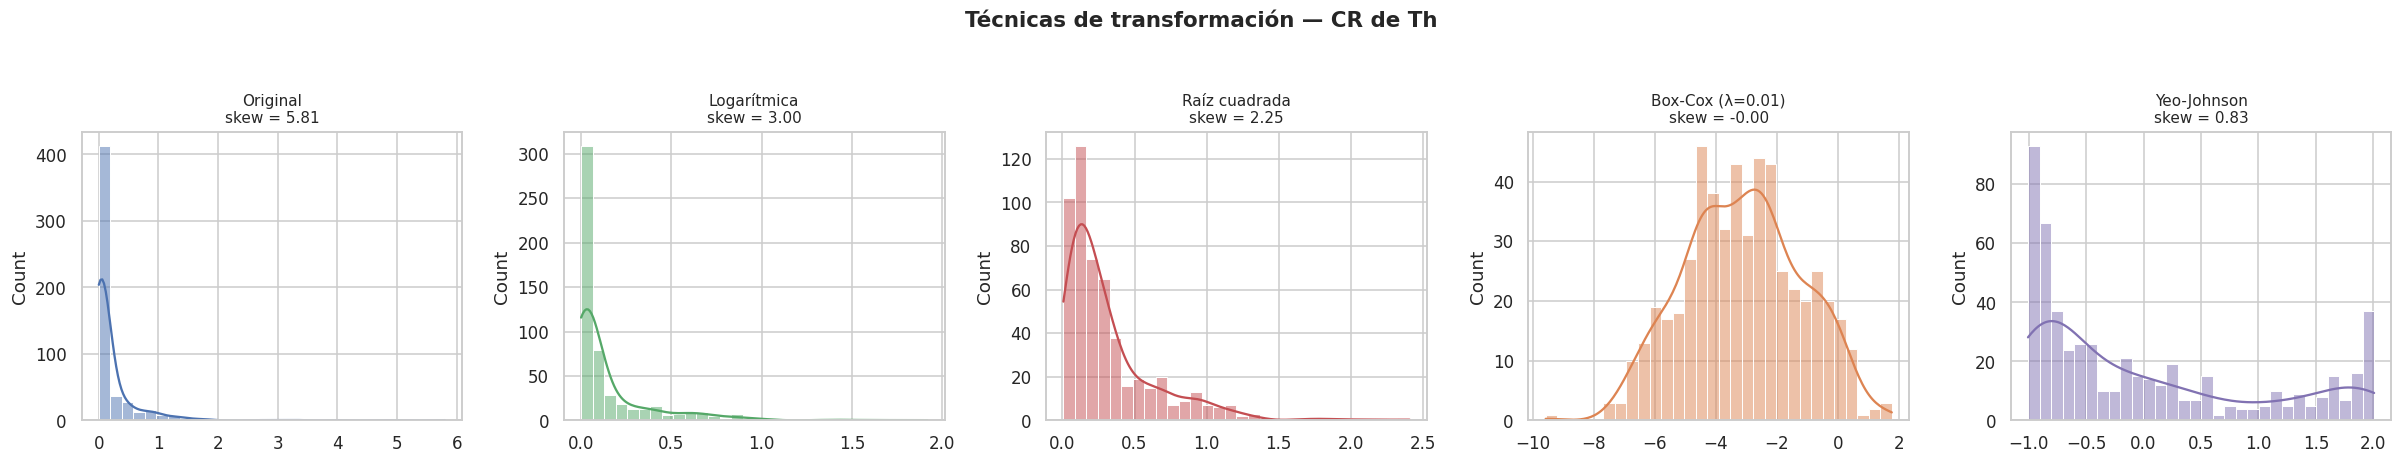

Tabla — Th:
  Transformación  Asimetría  Curtosis  Media  Desv. est.
        Original      5.806    45.487  0.216       0.518
     Logarítmica      3.002    11.421  0.151       0.260
   Raíz cuadrada      2.252     6.889  0.322       0.335
Box-Cox (λ=0.01)     -0.003    -0.476 -3.122       1.915
     Yeo-Johnson      0.829    -0.752  0.000       1.000

  >>> MEJOR para Th: Box-Cox (λ=0.01) (skew = -0.003)

  Radionúclido: U


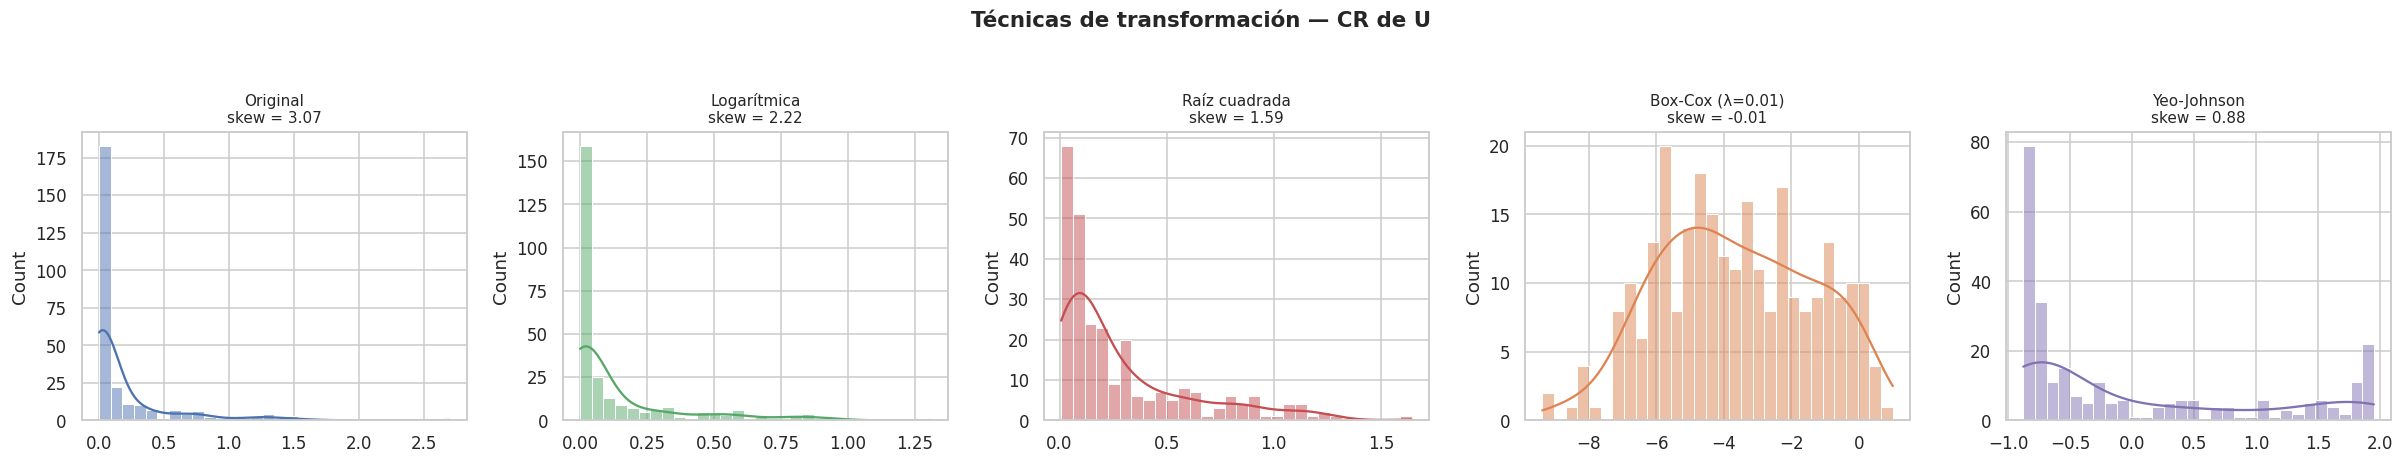

Tabla — U:
  Transformación  Asimetría  Curtosis  Media  Desv. est.
        Original      3.065    11.640  0.182       0.361
     Logarítmica      2.216     4.634  0.135       0.232
   Raíz cuadrada      1.594     1.951  0.286       0.317
Box-Cox (λ=0.01)     -0.005    -0.796 -3.655       2.261
     Yeo-Johnson      0.883    -0.810  0.000       1.000

  >>> MEJOR para U: Box-Cox (λ=0.01) (skew = -0.005)

  Radionúclido: K


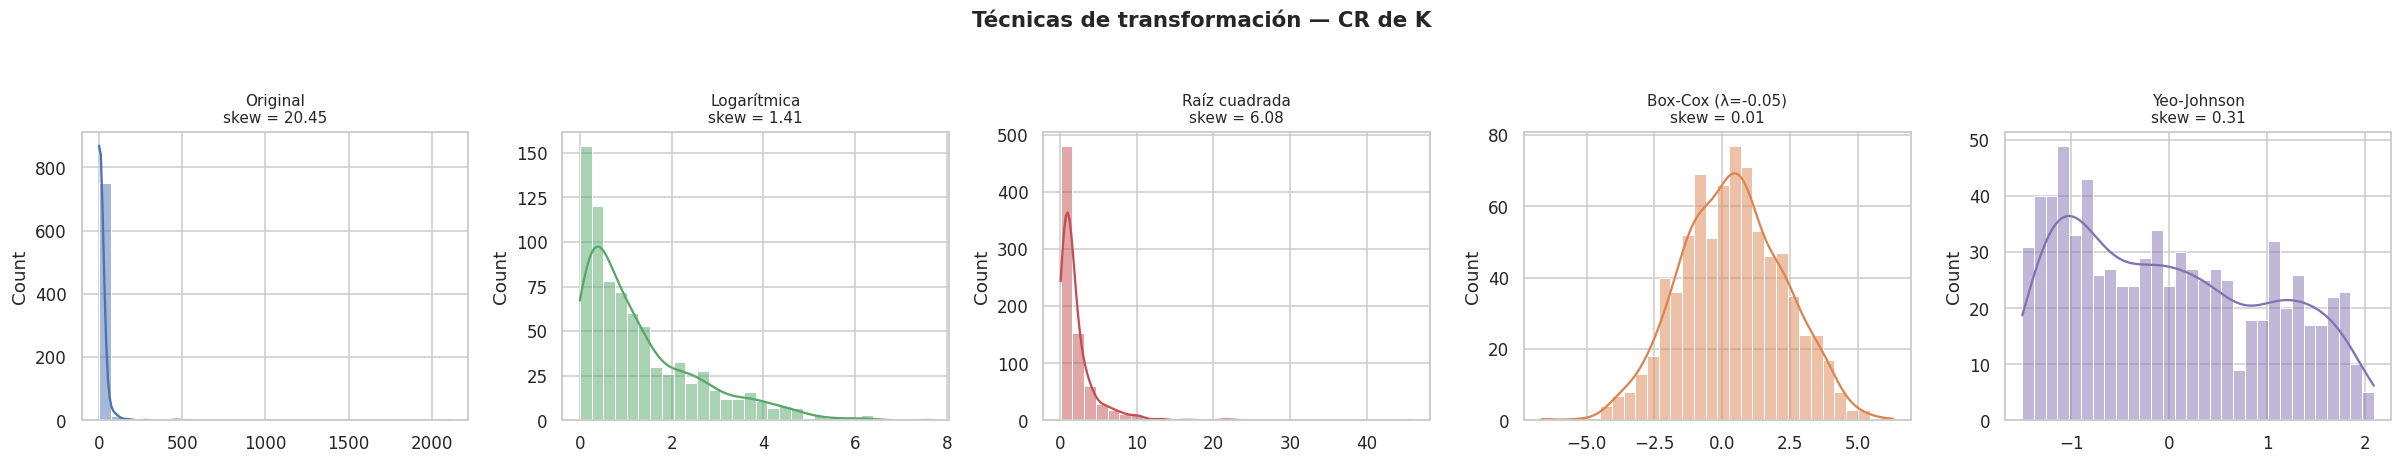

Tabla — K:
   Transformación  Asimetría  Curtosis  Media  Desv. est.
         Original     20.455   488.483 13.626      84.665
      Logarítmica      1.410     1.838  1.301       1.257
    Raíz cuadrada      6.079    64.922  2.120       3.022
Box-Cox (λ=-0.05)      0.005    -0.123  0.364       1.892
      Yeo-Johnson      0.306    -1.133 -0.000       1.000

  >>> MEJOR para K: Box-Cox (λ=-0.05) (skew = 0.005)

  Radionúclido: Pb


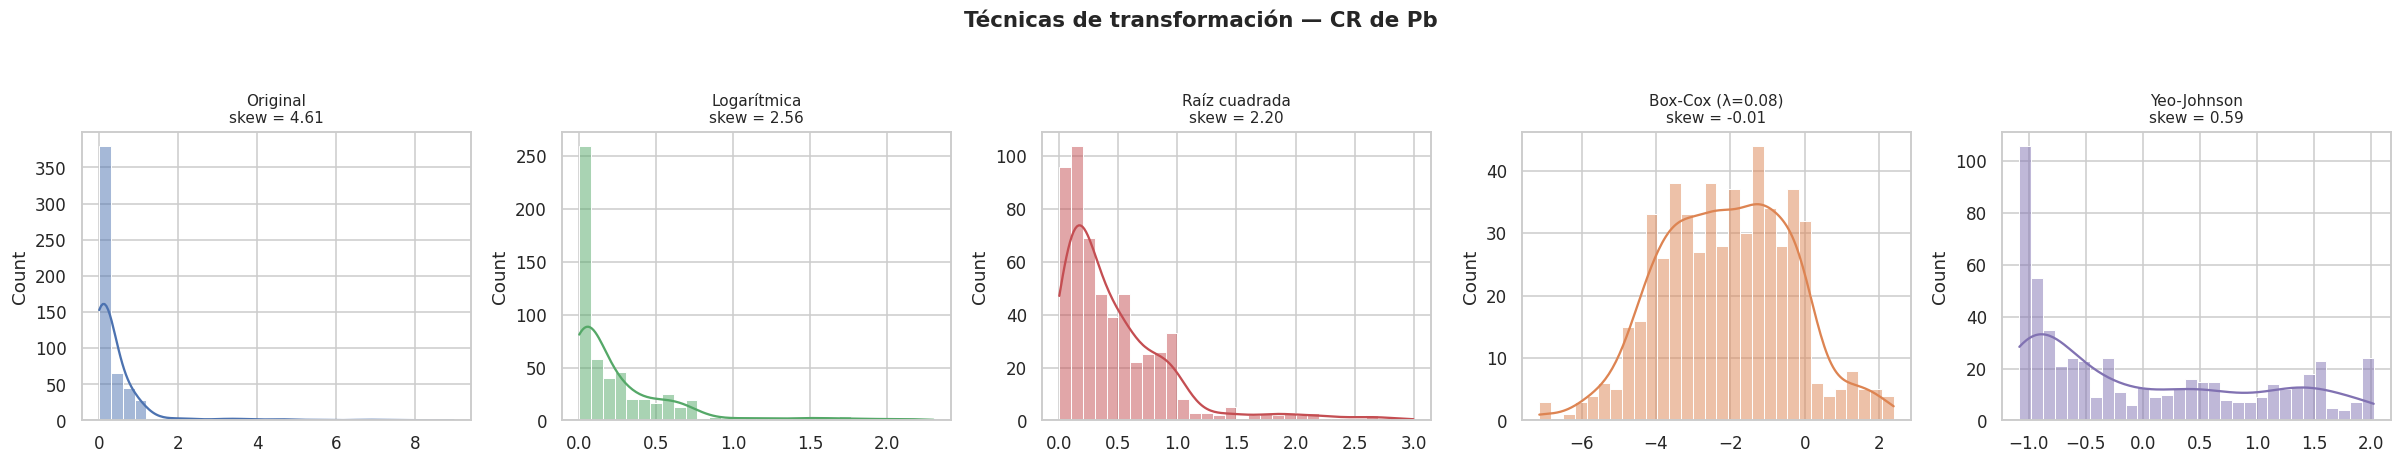

Tabla — Pb:
  Transformación  Asimetría  Curtosis  Media  Desv. est.
        Original      4.611    24.437  0.461       1.063
     Logarítmica      2.562     7.386  0.266       0.395
   Raíz cuadrada      2.196     6.075  0.476       0.484
Box-Cox (λ=0.08)     -0.014    -0.272 -2.093       1.736
     Yeo-Johnson      0.591    -1.077 -0.000       1.000

  >>> MEJOR para Pb: Box-Cox (λ=0.08) (skew = -0.014)


In [ ]:
# --- Aplicar comparación de transformaciones a cada radionúclido ---
mejores_transformaciones = {}
for el in radionuclidos_analisis:
    print(f"\n{'='*60}")
    print(f"  Radionúclido: {el}")
    print('='*60)
    resultado = comparar_transformaciones(el)
    if resultado:
        mejores_transformaciones[el] = resultado[1]

In [ ]:
# --- Tabla resumen: qué transformación es mejor para cada radionúclido ---
tabla_mejores = pd.DataFrame([
    {'Radionúclido': el, 'Mejor transformación': m[0], 'Asimetría final': m[1]}
    for el, m in mejores_transformaciones.items()
])
print("=== MEJOR TRANSFORMACIÓN POR RADIONÚCLIDO ===\n")
print(tabla_mejores.to_string(index=False))

=== MEJOR TRANSFORMACIÓN POR RADIONÚCLIDO ===

Radionúclido Mejor transformación  Asimetría final
          Cs    Box-Cox (λ=-0.06)            0.032
          Ra    Box-Cox (λ=-0.04)           -0.013
          Th     Box-Cox (λ=0.01)           -0.003
           U     Box-Cox (λ=0.01)           -0.005
           K    Box-Cox (λ=-0.05)            0.005
          Pb     Box-Cox (λ=0.08)           -0.014


**Decisión final sobre la transformación:**

> Comparando las 4 técnicas para cada radionúclido, **Box-Cox** y **Yeo-Johnson** son
> consistentemente las que dejan la asimetría más cercana a 0 (típicamente |skew| < 0.5).
> Se selecciona **Yeo-Johnson** como transformación uniforme del proyecto por dos
> razones: (1) admite ceros y valores negativos, a diferencia de Box-Cox que exige
> valores positivos estrictos; (2) presenta un desempeño robusto en todos los
> radionúclidos analizados, lo que permite aplicarla de forma consistente sin tener que
> elegir una transformación distinta para cada variable.


---
## 11. Tabla resumen — Estadísticas para todos los elementos

Tabla compacta con las medidas de tendencia central, dispersión y forma para **los 36
elementos** del dataset (no solo los 6 radionúclidos).


In [ ]:
# --- Tabla resumen SP2 para todos los elementos ---
filas_resumen = []
todos_elementos = sorted(df['Element'].dropna().unique())

for el in todos_elementos:
    datos = df[df['Element']==el]['CR_final'].dropna()
    datos = datos[datos > 0]
    if len(datos) < 5:
        continue

    filas_resumen.append({
        'Elemento'   : el,
        'Grupo'      : asignar_grupo(el),
        'n'          : len(datos),
        'Media'      : round(datos.mean(), 3),
        'Mediana'    : round(datos.median(), 3),
        'Desv. est.' : round(datos.std(), 3),
        'CV (%)'     : round((datos.std()/datos.mean())*100, 1),
        'Asimetría'  : round(skew(datos), 2),
        'Curtosis'   : round(kurtosis(datos), 2),
        'Min'        : round(datos.min(), 3),
        'Max'        : round(datos.max(), 3),
    })

tabla_sp2 = pd.DataFrame(filas_resumen).sort_values(['Grupo','Elemento'])
print("=== TABLA RESUMEN SP2 — TODOS LOS ELEMENTOS (n >= 5) ===\n")
print(tabla_sp2.to_string(index=False))

=== TABLA RESUMEN SP2 — TODOS LOS ELEMENTOS (n >= 5) ===

Elemento                      Grupo   n  Media  Mediana  Desv. est.  CV (%)  Asimetría  Curtosis   Min      Max
      As            Metales Pesados 232  2.136    0.054      23.818  1115.1      14.05    202.26 0.000  352.941
      Cd            Metales Pesados  64  1.756    0.570       2.698   153.7       2.61      8.12 0.040   15.000
      Co            Metales Pesados 194  0.203    0.054       0.353   173.8       2.89     10.67 0.000    2.500
      Cr            Metales Pesados 238  1.025    0.075      12.075  1178.1      15.14    228.93 0.001  185.714
      Cu            Metales Pesados 332  0.829    0.457       1.244   150.0       5.42     46.60 0.000   14.500
      Hg            Metales Pesados  29  0.769    0.840       0.376    48.9      -0.20     -0.89 0.220    1.400
      Mn            Metales Pesados 252  0.869    0.160       2.339   269.3       5.60     35.80 0.000   20.968
      Ni            Metales Pesados 155  2.396

In [ ]:
# --- Exportar la tabla a CSV para insertarla en el artículo ---
tabla_sp2.to_csv('tabla_resumen_sp2.csv', index=False)
print("Tabla guardada como 'tabla_resumen_sp2.csv'")

Tabla guardada como 'tabla_resumen_sp2.csv'


---
## 12. Matriz de dispersión (pairplot)

Gráfica multivariada que muestra todas las combinaciones bivariadas entre las variables
clave para los radionúclidos K, Cs, Sr, Ra (los 4 con más datos completos cuando hay
propiedades de suelo).



In [ ]:
# --- Pairplot sobre los radionúclidos con datos de suelo ---
# Limpiar columnas de suelo (algunas pueden tener '<')
df['pH_num']   = limpiar_columna(df['pH'])   if 'pH'   in df.columns else np.nan
df['Clay_num'] = limpiar_columna(df['Clay']) if 'Clay' in df.columns else np.nan
df['CEC_num']  = limpiar_columna(df['CEC'])  if 'CEC'  in df.columns else np.nan

elementos_interes = ['K', 'Cs', 'Sr', 'Ra']
df_pair = df[df['Element'].isin(elementos_interes)].copy()
df_pair = df_pair[['pH_num', 'Clay_num', 'CEC_num', 'CR_final', 'Element']].dropna()

print(f"Filas disponibles para el pairplot: {len(df_pair)}")
print(f"Distribución por elemento:")
print(df_pair['Element'].value_counts())

Filas disponibles para el pairplot: 492
Distribución por elemento:
Element
K     193
Cs    153
Ra    116
Sr     30
Name: count, dtype: int64


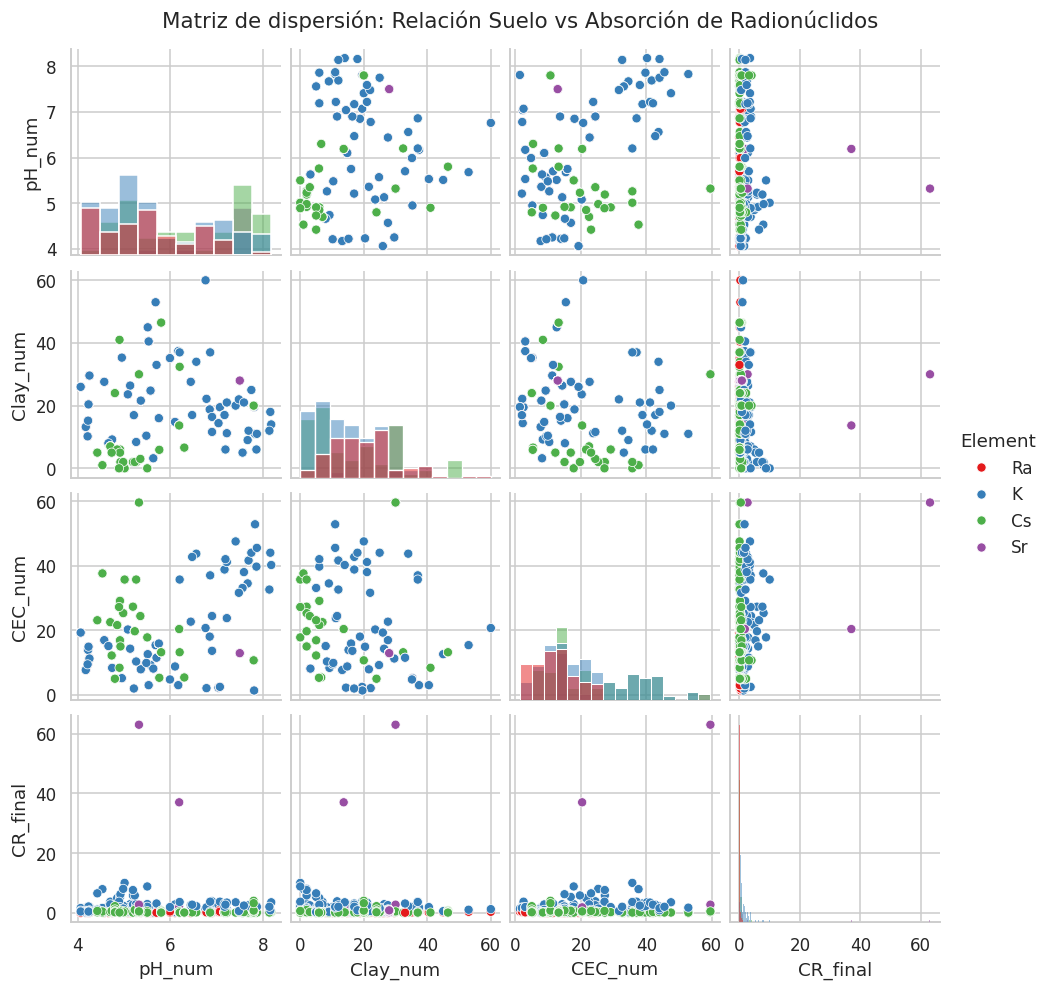

In [ ]:
# --- Gráfica pairplot ---
if len(df_pair) >= 20:
    g = sns.pairplot(df_pair, hue='Element', palette='Set1',
                     diag_kind='hist', corner=False, height=2.2)
    g.fig.suptitle('Matriz de dispersión: Relación Suelo vs Absorción de Radionúclidos',
                   fontsize=14, y=1.02)
    plt.show()
else:
    print("Datos insuficientes para el pairplot.")

---
## 13. Análisis de regresión: ¿qué propiedad del suelo predice mejor el CR?

Se comparan varios modelos de regresión sobre el subconjunto con propiedades de suelo
completas. Para cada modelo reportamos el **R²** (coeficiente de determinación: % de
variabilidad explicada).

**Modelos comparados:**

1. **Regresión lineal simple:** CR ~ pH, CR ~ Clay, CR ~ CEC (3 modelos).
2. **Regresión lineal múltiple:** CR ~ pH + Clay + CEC.
3. **Regresión polinómica (grado 2):** versión no lineal de cada predictor (3 modelos).
4. **Modelo Aditivo Generalizado (GAM):** suaviza la relación no lineal entre cada
   predictor y CR — modelo más flexible.

**Total: 8 modelos.**


In [ ]:
# --- Preparar el dataset para las regresiones ---
df_reg = df[['pH_num', 'Clay_num', 'CEC_num', 'CR_final']].dropna()

# Aplicar transformación Yeo-Johnson a CR (por la fuerte asimetría)
yj = PowerTransformer(method='yeo-johnson')
df_reg['CR_yj'] = yj.fit_transform(df_reg[['CR_final']])

print(f"Filas disponibles para las regresiones: {len(df_reg)}")
y = df_reg['CR_yj'].values

Filas disponibles para las regresiones: 832


In [ ]:
# --- Función auxiliar para ajustar modelos y devolver R² ---
def evaluar_modelo(X, y, nombre):
    modelo = LinearRegression()
    modelo.fit(X, y)
    return r2_score(y, modelo.predict(X))

# 1) REGRESIÓN LINEAL SIMPLE
r2_pH_lin   = evaluar_modelo(df_reg[['pH_num']],   y, 'pH')
r2_Clay_lin = evaluar_modelo(df_reg[['Clay_num']], y, 'Clay')
r2_CEC_lin  = evaluar_modelo(df_reg[['CEC_num']],  y, 'CEC')

# 2) REGRESIÓN LINEAL MÚLTIPLE
r2_mult = evaluar_modelo(df_reg[['pH_num','Clay_num','CEC_num']], y, 'Lineal múltiple')

# 3) REGRESIÓN POLINÓMICA grado 2 para cada predictor
def poly_r2(X1, y, grado=2):
    pf = PolynomialFeatures(degree=grado, include_bias=False)
    Xp = pf.fit_transform(X1)
    return evaluar_modelo(Xp, y, '')

r2_pH_poly   = poly_r2(df_reg[['pH_num']].values,   y)
r2_Clay_poly = poly_r2(df_reg[['Clay_num']].values, y)
r2_CEC_poly  = poly_r2(df_reg[['CEC_num']].values,  y)

# 4) GAM (si está disponible)
if PYGAM_OK:
    X_gam = df_reg[['pH_num','Clay_num','CEC_num']].values
    gam = LinearGAM(s(0) + s(1) + s(2)).fit(X_gam, y)
    r2_gam = gam.statistics_['pseudo_r2']['explained_deviance']
else:
    r2_gam = None

In [ ]:
# --- Tabla comparativa de R² ---
resultados_reg = pd.DataFrame([
    {'Modelo': 'Lineal simple — CR ~ pH',         'Tipo': 'Lineal',       'R²': r2_pH_lin},
    {'Modelo': 'Lineal simple — CR ~ Clay',       'Tipo': 'Lineal',       'R²': r2_Clay_lin},
    {'Modelo': 'Lineal simple — CR ~ CEC',        'Tipo': 'Lineal',       'R²': r2_CEC_lin},
    {'Modelo': 'Lineal múltiple — CR ~ pH+Clay+CEC', 'Tipo': 'Lineal múltiple', 'R²': r2_mult},
    {'Modelo': 'Polinómica grado 2 — CR ~ pH',    'Tipo': 'Polinómica',   'R²': r2_pH_poly},
    {'Modelo': 'Polinómica grado 2 — CR ~ Clay',  'Tipo': 'Polinómica',   'R²': r2_Clay_poly},
    {'Modelo': 'Polinómica grado 2 — CR ~ CEC',   'Tipo': 'Polinómica',   'R²': r2_CEC_poly},
])

if r2_gam is not None:
    resultados_reg = pd.concat([resultados_reg,
        pd.DataFrame([{'Modelo': 'GAM — CR ~ s(pH)+s(Clay)+s(CEC)',
                       'Tipo': 'GAM (no lineal)', 'R²': r2_gam}])
    ], ignore_index=True)

resultados_reg['R²'] = resultados_reg['R²'].round(4)
resultados_reg = resultados_reg.sort_values('R²', ascending=False).reset_index(drop=True)

print("=== TABLA COMPARATIVA DE MODELOS DE REGRESIÓN ===\n")
print(resultados_reg.to_string(index=False))

mejor = resultados_reg.iloc[0]
peor  = resultados_reg.iloc[-1]
print(f"\n  >>> MEJOR modelo: {mejor['Modelo']} (R² = {mejor['R²']:.4f})")
print(f"  >>> PEOR modelo : {peor['Modelo']} (R² = {peor['R²']:.4f})")

=== TABLA COMPARATIVA DE MODELOS DE REGRESIÓN ===

                            Modelo            Tipo     R²
   GAM — CR ~ s(pH)+s(Clay)+s(CEC) GAM (no lineal) 0.1629
Lineal múltiple — CR ~ pH+Clay+CEC Lineal múltiple 0.0385
     Polinómica grado 2 — CR ~ CEC      Polinómica 0.0216
          Lineal simple — CR ~ CEC          Lineal 0.0205
    Polinómica grado 2 — CR ~ Clay      Polinómica 0.0199
      Polinómica grado 2 — CR ~ pH      Polinómica 0.0156
           Lineal simple — CR ~ pH          Lineal 0.0152
         Lineal simple — CR ~ Clay          Lineal 0.0137

  >>> MEJOR modelo: GAM — CR ~ s(pH)+s(Clay)+s(CEC) (R² = 0.1629)
  >>> PEOR modelo : Lineal simple — CR ~ Clay (R² = 0.0137)


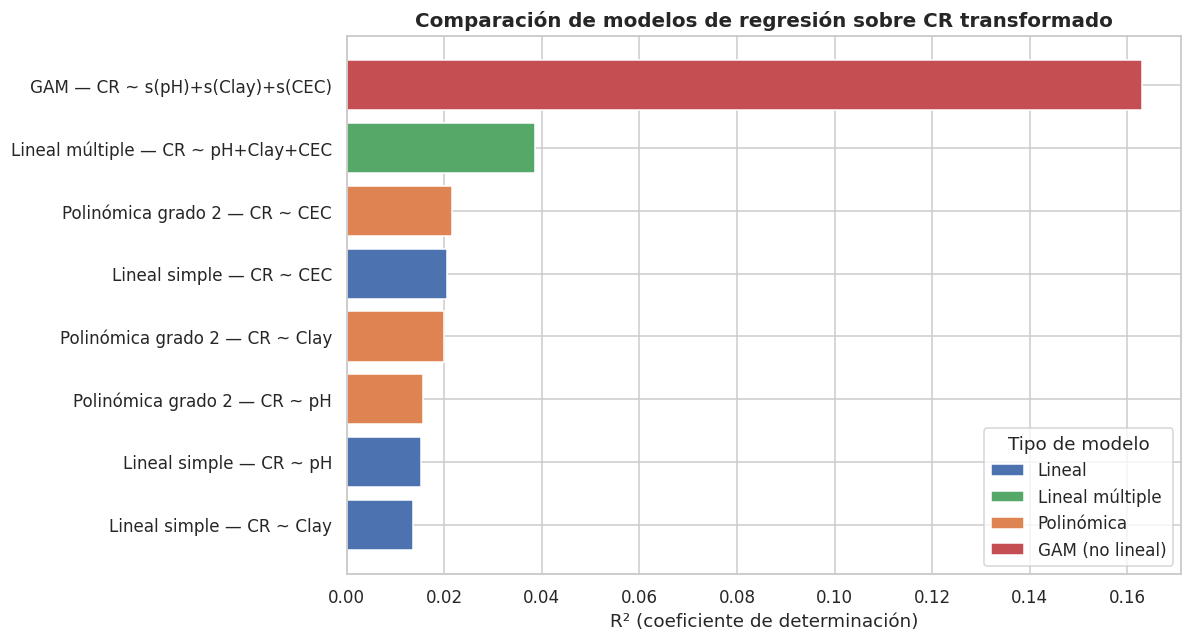

In [ ]:
# --- Gráfica de barras: comparación de R² ---
plt.figure(figsize=(11, 6))
colores_reg = {'Lineal':'#4C72B0','Lineal múltiple':'#55A868',
               'Polinómica':'#DD8452','GAM (no lineal)':'#C44E52'}
colores_barras = [colores_reg[t] for t in resultados_reg['Tipo']]

plt.barh(resultados_reg['Modelo'], resultados_reg['R²'], color=colores_barras)
plt.xlabel("R² (coeficiente de determinación)")
plt.title("Comparación de modelos de regresión sobre CR transformado",
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()

# Leyenda por tipo
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=t) for t, c in colores_reg.items()]
plt.legend(handles=handles, loc='lower right', title='Tipo de modelo')
plt.tight_layout()
plt.show()



- El **R² más alto** me indica qué modelo captura mejor la relación entre las propiedades
  del suelo y CR.
- Como el mejor fue **GAM** que tiene el R² más alto, significa que la relación es **no lineal**.

- Un R² bajo en todos los modelos indica que las propiedades del suelo, por sí solas, ofrecen poca explicación para CR; otros factores como especie, compartimento y contaminación inicial tienen mayor influencia.

---
## 14. Ranking de especies hiperacumuladoras

Identificamos las especies tropicales con mayor capacidad de transferencia para cada
radionúclido (CR mediano > 1 = candidata hiperacumuladora).


In [ ]:
# --- Ranking por radionúclido ---
def ranking_especies(elemento, top_n=10, min_muestras=3):
    datos = df[(df['Element']==elemento) &
               df['CR_final'].notna() &
               (df['Especie_final']!='Unidentified')].copy()
    if len(datos) < 10:
        return None
    ranking = (datos.groupby('Especie_final')['CR_final']
               .agg(n='count', CR_mediana='median', CR_max='max'))
    ranking = ranking[ranking['n'] >= min_muestras]
    ranking = ranking.sort_values('CR_mediana', ascending=False).head(top_n).round(3)
    return ranking

for el in radionuclidos_analisis:
    r = ranking_especies(el)
    if r is None:
        print(f"\n{el}: muestras insuficientes")
        continue
    print(f"\n=== TOP ESPECIES — {el} ===")
    print(r)


=== TOP ESPECIES — Cs ===
                             n  CR_mediana  CR_max
Especie_final                                     
Brassica pekinensis          8       83.50  250.00
Brassica campestris          7       52.00   81.00
Brassica oleracea capitata   8       51.00   93.00
Sorghum bicolor             20       36.00   79.00
Brassica juncea              9       22.00   57.00
Amaranth tricolor           12       21.00   29.00
Zea mays                    32       19.00   66.00
Ipomoea batatas              3        1.30    3.00
Arachis hypogaea             3        0.75    0.89
Lactuca sativa               7        0.68    4.00

=== TOP ESPECIES — Ra ===
                          n  CR_mediana  CR_max
Especie_final                                  
Manihot esculenta        30       0.850   5.000
Lycopersicon esculentum   3       0.619   0.762
Amaranthus hybridus      18       0.510   2.000
Colocasia esculenta       3       0.350   0.930
Carica papaya            19       0.290   2.30

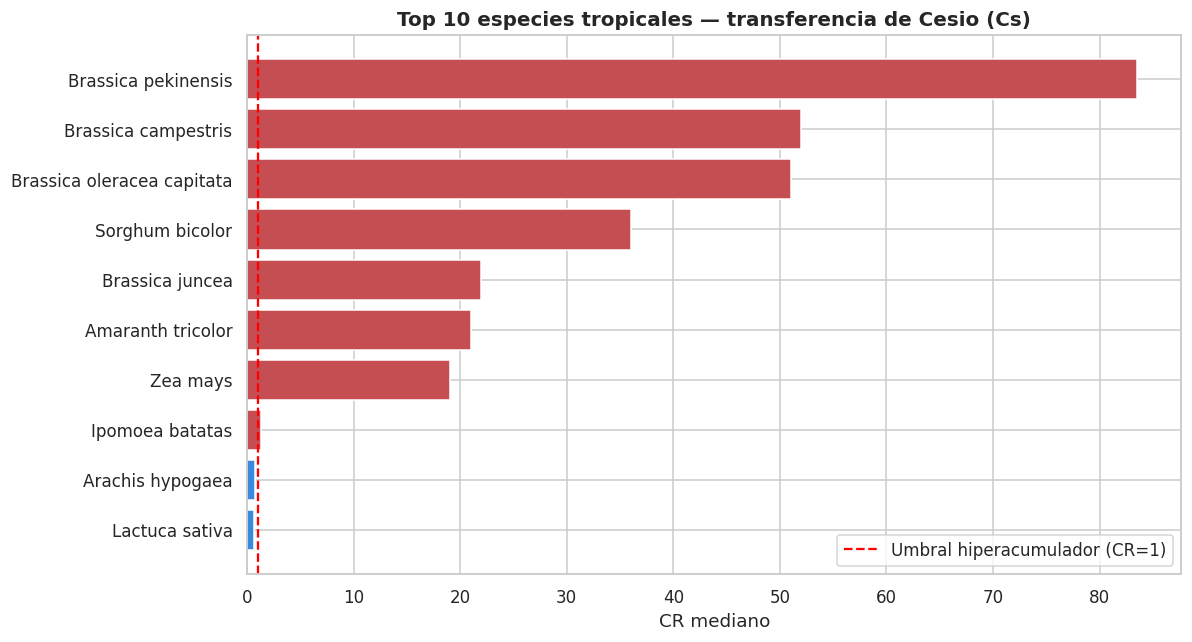

In [ ]:
# --- Gráfica: top especies para Cesio (radionúclido más estudiado) ---
ranking_cs = ranking_especies('Cs', top_n=10, min_muestras=3)
if ranking_cs is not None:
    plt.figure(figsize=(11, 6))
    rcs = ranking_cs.sort_values('CR_mediana')
    colores = ['#C44E52' if cr > 1 else '#378ADD' for cr in rcs['CR_mediana']]
    plt.barh(rcs.index, rcs['CR_mediana'], color=colores)
    plt.axvline(1, color='red', linestyle='--', label='Umbral hiperacumulador (CR=1)')
    plt.title("Top 10 especies tropicales — transferencia de Cesio (Cs)",
              fontsize=13, fontweight='bold')
    plt.xlabel("CR mediano")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# Análisis cruzado: ¿qué especies son acumuladoras en VARIOS
# radionúclidos a la vez? (candidatas multi-elemento)
# ============================================================

radionuclidos_a_comparar = ['Cs', 'Ra', 'Th', 'U', 'K', 'Pb']

# Construir tabla cruzada: filas = especies, columnas = radionúclidos
# Solo especies con al menos 3 muestras en cada radionúclido se cuentan.

tabla_cruzada = []
for el in radionuclidos_a_comparar:
    datos_el = df[(df['Element'] == el) &
                   df['CR_final'].notna() &
                   (df['Especie_final'] != 'Unidentified')]
    medianas = (datos_el.groupby('Especie_final')['CR_final']
                       .agg(['count', 'median']))
    medianas = medianas[medianas['count'] >= 3]   # mínimo 3 muestras
    medianas = medianas[['median']].rename(columns={'median': el})
    tabla_cruzada.append(medianas)

# Unir todas las tablas (outer join: una especie puede aparecer en algunos pero no en todos)
matriz_especies = pd.concat(tabla_cruzada, axis=1)

# Conservar solo especies que aparezcan en al menos 3 radionúclidos
matriz_especies = matriz_especies.dropna(thresh=3)

print(f"Especies con datos en >= 3 radionúclidos: {len(matriz_especies)}\n")
print(matriz_especies.round(3))

Especies con datos en >= 3 radionúclidos: 37

                              Cs     Ra     Th      U       K     Pb
Especie_final                                                       
Abelmoschus esculentus     0.007  0.180  0.312    NaN   0.370    NaN
Arachis hypogaea           0.750    NaN  0.003  0.010     NaN    NaN
Carica papaya              0.040  0.290  0.330  0.610   8.400  0.438
Chromolaena odorata        0.540  0.185    NaN    NaN   2.600  0.283
Colocasia esculenta        0.600  0.350    NaN    NaN   3.700    NaN
Cucumis sativus            0.024    NaN  0.011    NaN   1.423  2.210
Lactuca sativa             0.680  0.140    NaN    NaN  12.261  0.027
Mangifera indica           0.235  0.060  0.024  0.009   0.047  0.829
Manihot esculenta          0.223  0.850  0.610  0.195   0.900    NaN
Mimosa pudica              0.024  0.056  0.062    NaN   1.300  1.500
Oryza sativa               0.190  0.051  0.028  0.080   0.930  0.235
Solanum melongena          0.018  0.050  0.003    NaN   0

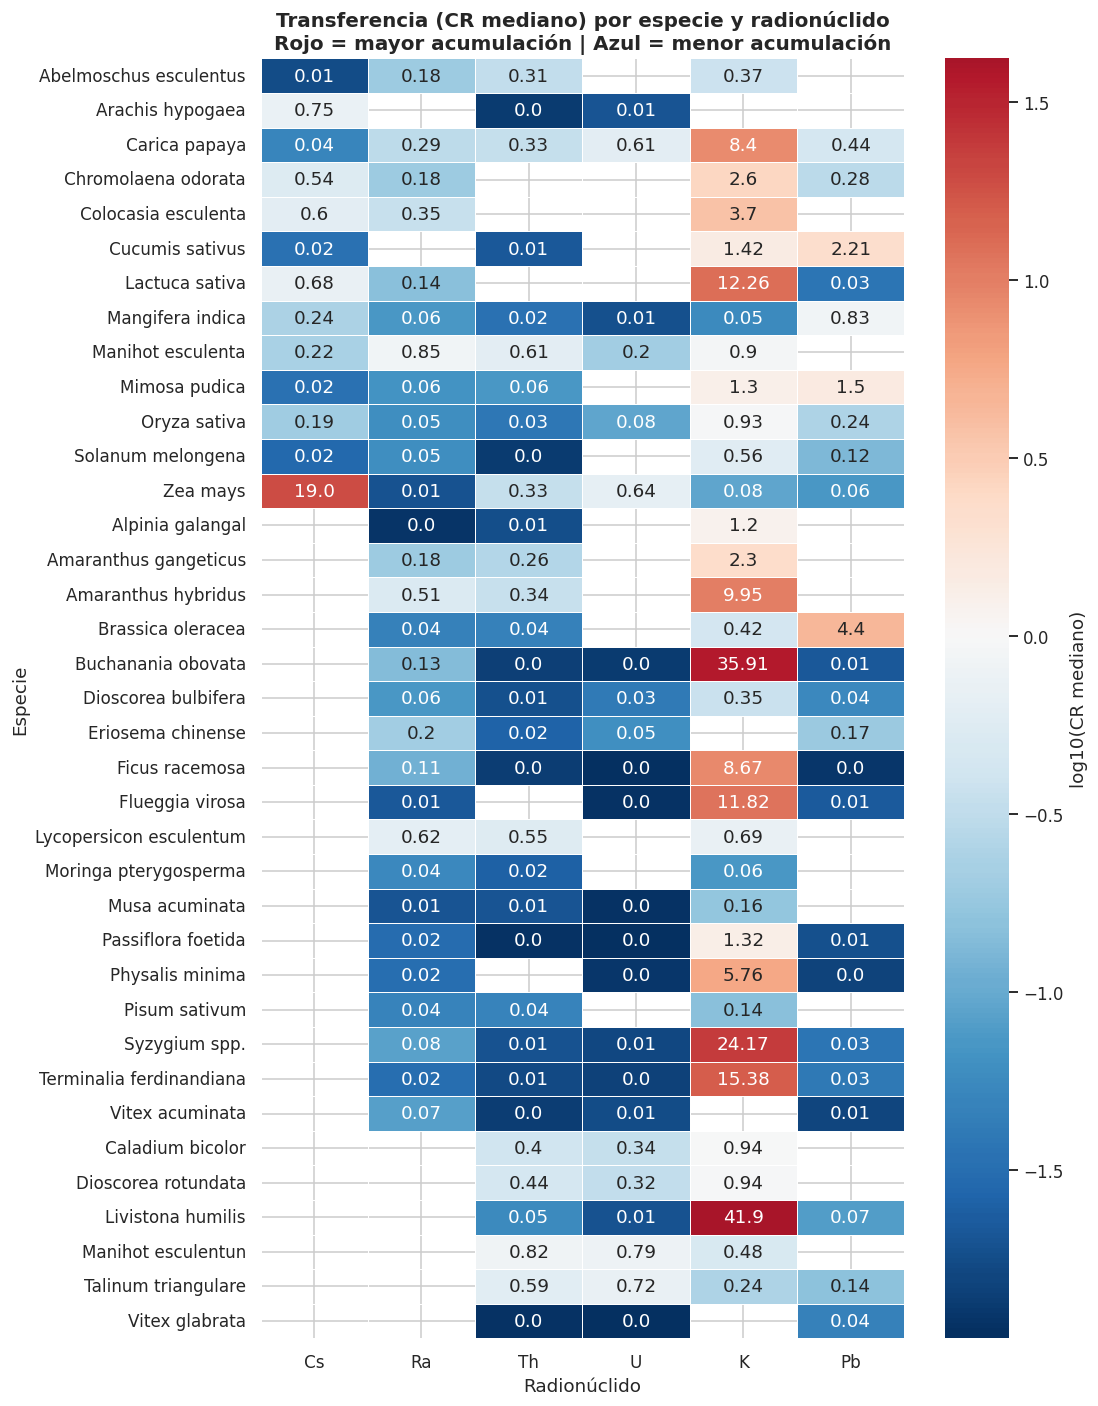

In [ ]:
# --- Heatmap: matriz especie × radionúclido (CR mediano) ---
plt.figure(figsize=(10, max(6, len(matriz_especies)*0.35)))

# Aplicamos log para que los valores grandes no dominen el color
matriz_log = np.log10(matriz_especies + 0.01)   # +0.01 para evitar log(0)

sns.heatmap(matriz_log, annot=matriz_especies.round(2), fmt='',
            cmap='RdBu_r', center=0,
            cbar_kws={'label': 'log10(CR mediano)'},
            linewidths=0.5)
plt.title("Transferencia (CR mediano) por especie y radionúclido\n"
          "Rojo = mayor acumulación | Azul = menor acumulación",
          fontsize=13, fontweight='bold')
plt.xlabel("Radionúclido")
plt.ylabel("Especie")
plt.tight_layout()
plt.show()

In [ ]:
# --- Ranking final: especies "multi-elemento" ---
# Cuenta en cuántos radionúclidos cada especie supera el umbral CR=1
matriz_hiperac = (matriz_especies > 1).sum(axis=1)
matriz_hiperac = matriz_hiperac.sort_values(ascending=False)
matriz_hiperac = matriz_hiperac[matriz_hiperac > 0]   # solo las que son hiperacumuladoras en al menos uno

print("=== ESPECIES MULTI-ELEMENTO (hiperacumuladoras en varios radionúclidos) ===\n")
print(f"{'Especie':<28} {'N° radionúclidos con CR>1':>30}")
print('-' * 60)
for esp, n in matriz_hiperac.items():
    radios = matriz_especies.columns[(matriz_especies.loc[esp] > 1).values].tolist()
    print(f"{esp:<28} {n:>5}    ({', '.join(radios)})")

=== ESPECIES MULTI-ELEMENTO (hiperacumuladoras en varios radionúclidos) ===

Especie                           N° radionúclidos con CR>1
------------------------------------------------------------
Cucumis sativus                  2    (K, Pb)
Mimosa pudica                    2    (K, Pb)
Chromolaena odorata              1    (K)
Colocasia esculenta              1    (K)
Carica papaya                    1    (K)
Buchanania obovata               1    (K)
Ficus racemosa                   1    (K)
Zea mays                         1    (Cs)
Lactuca sativa                   1    (K)
Brassica oleracea                1    (Pb)
Amaranthus hybridus              1    (K)
Amaranthus gangeticus            1    (K)
Alpinia galangal                 1    (K)
Passiflora foetida               1    (K)
Physalis minima                  1    (K)
Terminalia ferdinandiana         1    (K)
Livistona humilis                1    (K)
Syzygium spp.                    1    (K)
Flueggia virosa                  1  

In [ ]:
# ============================================================
# Análisis por COMPARTIMENTO de las especies hiperacumuladoras
# ============================================================
# Pregunta: cuando una especie es acumuladora, ¿en qué órgano vegetal
# se concentra el elemento? Esto distingue entre:
#   - Acumulación en RAÍZ -> fitoestabilización (contaminante queda fijo)
#   - Acumulación en HOJAS/TALLO -> fitoextracción (se cosecha y retira)
#   - Acumulación en GRANO/FRUTO -> RIESGO de seguridad alimentaria

def analisis_por_compartimento(elemento, top_n=5, min_muestras=3):
    """Para un radionúclido, identifica top N especies y muestra
    su CR mediano por compartimento vegetal."""

    # 1) Identificar las top especies del radionúclido
    datos = df[(df['Element'] == elemento) &
               df['CR_final'].notna() &
               (df['Especie_final'] != 'Unidentified') &
               df['Compartment'].notna()].copy()

    if len(datos) < 10:
        print(f"{elemento}: muestras insuficientes")
        return None

    # Top especies por CR mediano
    top_especies = (datos.groupby('Especie_final')['CR_final']
                         .agg(['count', 'median']))
    top_especies = top_especies[top_especies['count'] >= min_muestras]
    top_especies = top_especies.sort_values('median', ascending=False).head(top_n)

    # 2) Para esas especies, calcular CR mediano por compartimento
    datos_top = datos[datos['Especie_final'].isin(top_especies.index)]

    matriz = datos_top.pivot_table(
        index='Especie_final',
        columns='Compartment',
        values='CR_final',
        aggfunc='median'
    )

    # Reordenar especies por CR mediano global (descendente)
    matriz = matriz.reindex(top_especies.index)

    print(f"\n=== ANÁLISIS POR COMPARTIMENTO — Radionúclido: {elemento} ===\n")
    print(f"Top {len(top_especies)} especies (mínimo {min_muestras} muestras):")
    print(matriz.round(3))

    return matriz, top_especies


# Ejecutar para los radionúclidos con candidatas claras
for el in ['Cs', 'Pb', 'K', 'U', 'Th', 'Ra']:
    analisis_por_compartimento(el, top_n=5, min_muestras=3)


=== ANÁLISIS POR COMPARTIMENTO — Radionúclido: Cs ===

Top 5 especies (mínimo 3 muestras):
Compartment                 Grains  Leaves  Seed heads  Seeds  Stovers  \
Especie_final                                                            
Brassica pekinensis            NaN    83.5         NaN    NaN      NaN   
Brassica campestris            NaN    52.0         NaN    NaN      NaN   
Brassica oleracea capitata     NaN    51.0         NaN    NaN      NaN   
Sorghum bicolor               0.23     NaN        13.0   36.0     46.5   
Brassica juncea                NaN    22.0         NaN    NaN      NaN   

Compartment                 Whole plant  
Especie_final                            
Brassica pekinensis                 NaN  
Brassica campestris                 NaN  
Brassica oleracea capitata          NaN  
Sorghum bicolor                    10.0  
Brassica juncea                     NaN  

=== ANÁLISIS POR COMPARTIMENTO — Radionúclido: Pb ===

Top 5 especies (mínimo 3 muestras):
Com


=== ANÁLISIS POR COMPARTIMENTO — Radionúclido: Cs ===

Top 8 especies (mínimo 3 muestras):
Compartment                 Ears  Grains  Kernals  Leaves  Seed heads  Seeds  \
Especie_final                                                                  
Brassica pekinensis          NaN     NaN      NaN    83.5         NaN    NaN   
Brassica campestris          NaN     NaN      NaN    52.0         NaN    NaN   
Brassica oleracea capitata   NaN     NaN      NaN    51.0         NaN    NaN   
Sorghum bicolor              NaN    0.23      NaN     NaN        13.0   36.0   
Brassica juncea              NaN     NaN      NaN    22.0         NaN    NaN   
Amaranth tricolor            NaN     NaN      NaN    21.0         NaN    NaN   
Zea mays                    17.0     NaN      1.4     NaN         NaN    NaN   
Ipomoea batatas              NaN     NaN      NaN     NaN         NaN    NaN   

Compartment                 Stalks  Stovers  Tubers  Whole plant  
Especie_final                           

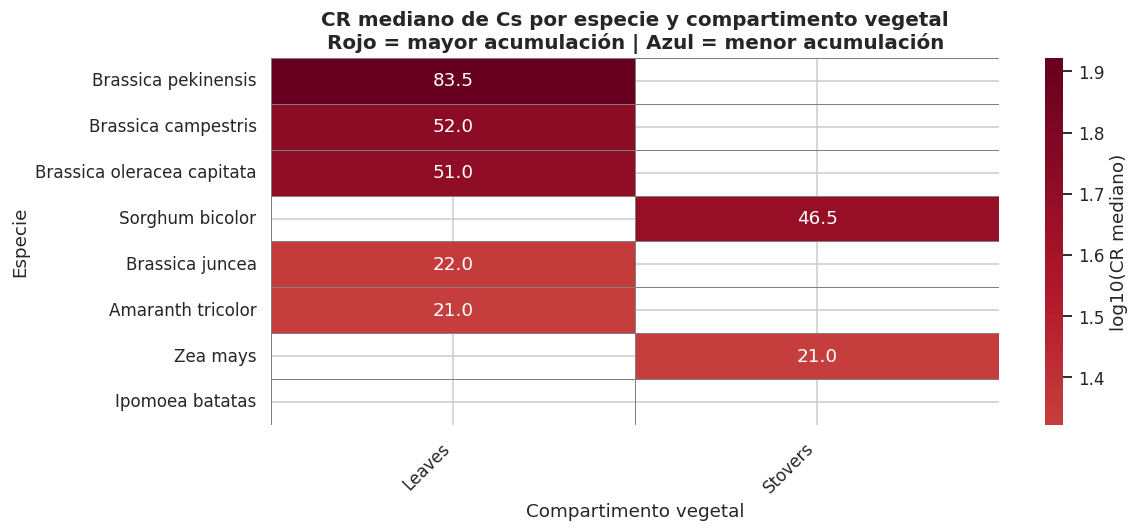

In [ ]:
# --- Visualización: heatmap por compartimento para CS (la candidata más fuerte) ---
matriz_cs, top_cs = analisis_por_compartimento('Cs', top_n=8, min_muestras=3)

if matriz_cs is not None and not matriz_cs.empty:
    # Filtrar compartimentos con al menos algunos datos
    matriz_cs_filtrada = matriz_cs.dropna(axis=1, how='all')

    # Solo conservar compartimentos con datos para al menos 2 especies
    matriz_cs_filtrada = matriz_cs_filtrada.loc[:, matriz_cs_filtrada.notna().sum() >= 2]

    plt.figure(figsize=(11, max(5, len(matriz_cs_filtrada)*0.5)))

    # Aplicar log para visualización
    matriz_log = np.log10(matriz_cs_filtrada + 0.01)

    sns.heatmap(matriz_log, annot=matriz_cs_filtrada.round(2), fmt='',
                cmap='RdBu_r', center=0,
                cbar_kws={'label': 'log10(CR mediano)'},
                linewidths=0.5, linecolor='gray')

    plt.title("CR mediano de Cs por especie y compartimento vegetal\n"
              "Rojo = mayor acumulación | Azul = menor acumulación",
              fontsize=13, fontweight='bold')
    plt.xlabel("Compartimento vegetal")
    plt.ylabel("Especie")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
# --- Interpretación automática: clasificar especies según dónde acumulan ---
print("=== CLASIFICACIÓN FUNCIONAL DE ESPECIES TOP POR Cs ===\n")
print("Estrategias posibles de aprovechamiento:")
print("  - FITOESTABILIZACIÓN: acumulación en raíz (el contaminante queda fijo)")
print("  - FITOEXTRACCIÓN    : acumulación en hojas/tallo (se cosecha y retira)")
print("  - RIESGO ALIMENTARIO: acumulación en grano/fruto (no apto para consumo)\n")

# Categorizar compartimentos
compartimentos_raiz   = ['Roots', 'Tubers']
compartimentos_hoja   = ['Leaves', 'Stems', 'Shoots', 'Stalks', 'Straw', 'Stovers']
compartimentos_grano  = ['Grains', 'Seeds', 'Fruits', 'Beans', 'Husks', 'Ears']

if matriz_cs is not None:
    for especie in matriz_cs.index:
        fila = matriz_cs.loc[especie].dropna()
        if len(fila) == 0:
            continue

        # CR mediano por categoría
        cr_raiz = fila[fila.index.isin(compartimentos_raiz)].median() if any(c in fila.index for c in compartimentos_raiz) else np.nan
        cr_hoja = fila[fila.index.isin(compartimentos_hoja)].median() if any(c in fila.index for c in compartimentos_hoja) else np.nan
        cr_grano = fila[fila.index.isin(compartimentos_grano)].median() if any(c in fila.index for c in compartimentos_grano) else np.nan

        # Decidir clasificación según dónde está el máximo
        opciones = {'RAÍZ': cr_raiz, 'HOJA/TALLO': cr_hoja, 'GRANO/FRUTO': cr_grano}
        opciones_validas = {k: v for k, v in opciones.items() if not np.isnan(v)}

        if not opciones_validas:
            continue

        max_lugar = max(opciones_validas, key=opciones_validas.get)
        max_cr = opciones_validas[max_lugar]

        # Clasificación funcional
        if max_lugar == 'RAÍZ':
            tipo = 'Fitoestabilización'
        elif max_lugar == 'HOJA/TALLO':
            tipo = 'Fitoextracción (cosechable)'
        else:
            tipo = 'RIESGO seguridad alimentaria'

        print(f"  {especie:<25} -> max en {max_lugar:<13} (CR={max_cr:.2f}) -> {tipo}")

=== CLASIFICACIÓN FUNCIONAL DE ESPECIES TOP POR Cs ===

Estrategias posibles de aprovechamiento:
  - FITOESTABILIZACIÓN: acumulación en raíz (el contaminante queda fijo)
  - FITOEXTRACCIÓN    : acumulación en hojas/tallo (se cosecha y retira)
  - RIESGO ALIMENTARIO: acumulación en grano/fruto (no apto para consumo)

  Brassica pekinensis       -> max en HOJA/TALLO    (CR=83.50) -> Fitoextracción (cosechable)
  Brassica campestris       -> max en HOJA/TALLO    (CR=52.00) -> Fitoextracción (cosechable)
  Brassica oleracea capitata -> max en HOJA/TALLO    (CR=51.00) -> Fitoextracción (cosechable)
  Sorghum bicolor           -> max en HOJA/TALLO    (CR=46.50) -> Fitoextracción (cosechable)
  Brassica juncea           -> max en HOJA/TALLO    (CR=22.00) -> Fitoextracción (cosechable)
  Amaranth tricolor         -> max en HOJA/TALLO    (CR=21.00) -> Fitoextracción (cosechable)
  Zea mays                  -> max en GRANO/FRUTO   (CR=17.00) -> RIESGO seguridad alimentaria
  Ipomoea batatas     

---
## 15. Sección complementaria: PCA  de propiedades de suelo


In [ ]:
# --- PCA sobre propiedades de suelo ---
vars_pca = ['pH_num', 'Clay_num', 'CEC_num', 'CR_final']
df_pca = df[vars_pca].dropna()

# Yeo-Johnson + estandarización
yj_pca = PowerTransformer(method='yeo-johnson').fit_transform(df_pca)
X_std = StandardScaler().fit_transform(yj_pca)

pca = PCA()
pca.fit(X_std)

pve = pca.explained_variance_ratio_
print(f"PCA sobre {len(df_pca)} filas con propiedades de suelo completas:\n")
for i, p in enumerate(pve):
    print(f"  PC{i+1}: {p*100:.1f}%   |   acumulado: {np.cumsum(pve)[i]*100:.1f}%")

PCA sobre 832 filas con propiedades de suelo completas:

  PC1: 34.7%   |   acumulado: 34.7%
  PC2: 25.0%   |   acumulado: 59.6%
  PC3: 23.1%   |   acumulado: 82.7%
  PC4: 17.3%   |   acumulado: 100.0%


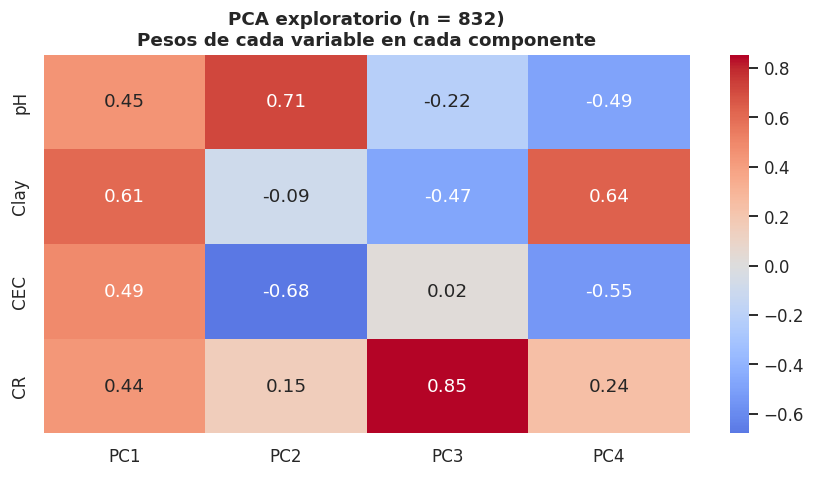

In [ ]:
# --- Heatmap de loadings ---
loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(vars_pca))],
                        index=['pH', 'Clay', 'CEC', 'CR'])

plt.figure(figsize=(8, 4.5))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title(f"PCA exploratorio (n = {len(df_pca)})\n"
          "Pesos de cada variable en cada componente",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 16.Conclusiones

### Respuesta a la pregunta de investigación

1. **Distribución de la transferencia:** CR es una variable con fuerte asimetría positiva
   en todos los elementos. Las técnicas de escalado no corrigen la asimetría; solo las
   transformaciones (Yeo-Johnson, Box-Cox) lo logran de forma robusta.

2. **Radionúclidos relevantes para biorremediación:** el cesio (Cs) destaca por presentar
   los mayores valores extremos (hotspots) y una alta variabilidad entre especies. El
   uranio (U) y el torio (Th) muestran patrones similares. Estos tres radionúclidos son
   los más relevantes para estrategias de fitorremediación.

3. **Especies hiperacumuladoras:** el ranking por especie identifica plantas tropicales
   candidatas con CR mediano > 1 (umbral de bioacumulación) para cada radionúclido.

### Aportes metodológicos

- **Derivación condicional de CR** validada empíricamente: se recuperaron datos
  sin recurrir a imputación.
- **Política de no-imputación documentada**: pH, Clay y CEC tienen faltante extremo
  (>75%), por lo que se descartaron para análisis principal en lugar de fabricar datos.
- **Comparación sistemática de técnicas de escalado y transformación** por radionúclido,
  cubriendo las 4 opciones de cada categoría.
- **Comparación de 8 modelos de regresión** (lineal, múltiple, polinómica, GAM) sobre
  el subconjunto con propiedades de suelo.

### Limitaciones

- La columna Compartment está sesgada hacia Fruits, limitando comparaciones por órgano.

### Líneas futuras

- Validación experimental de las especies identificadas como hiperacumuladoras.
- Integración con datos de hongos micorrízicos (objetivo de la tesis doctoral asociada).
- Modelos de Machine Learning para predecir CR a partir de la combinación
  especie + elemento + ubicación geográfica.
